# **Dolfin Varshev**
* A link to my kaggle profile: https://www.kaggle.com/dolfinvarshev

# **Aviv Bachana**
* A link to my kaggle profile: https://www.kaggle.com/avivbach

In [ ]:
# Competition link
competition_url = "https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques"
print(f"Kaggle Competition: {competition_url}")



Kaggle Competition: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques


#**House Prices Prediction - Advanced Regression Techniques**

## Overview

In this notebook, we aim to predict house prices in Ames, Iowa, using the "House Prices - Advanced Regression Techniques" dataset provided by Kaggle. Our primary objective is to develop a robust and accurate predictive model by experimenting with a variety of regression techniques, including ensemble models.

To achieve this, we will preprocess the data by handling missing values, engineering new features, and applying data transformations such as scaling with StandardScaler and encoding categorical variables using OneHotEncoder. Principal Component Analysis (PCA) will also be explored to reduce dimensionality and improve model efficiency.

The competition challenges us to accurately predict sale prices, and we will approach this by building several machine learning models-including ensemble methods-and fine-tuning them through hyperparameter optimization. Evaluation metrics will include RMSE, R², MAE and MSE, which help assess both model accuracy and explanatory power.

For data manipulation and visualization, we will use tools such as pandas, numpy, matplotlib, and seaborn to explore relationships, identify trends, and communicate results effectively.

Throughout this notebook, we will provide clear visualizations and detailed explanations to ensure transparency, reproducibility, and insight into our methodology and decisions. Our final goal is to select the best-performing model for submission and to fully understand the process that led to it.

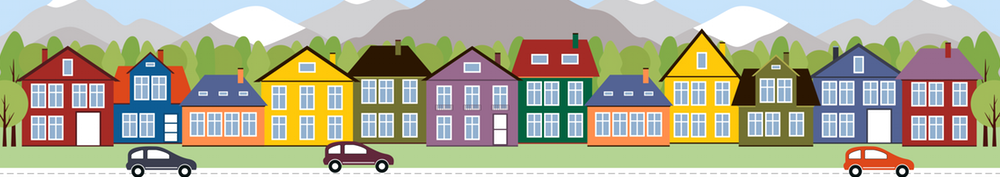

#**Imports and Definitions**

In [ ]:
import math
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import AdaBoostRegressor, BaggingRegressor, RandomForestRegressor
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns



# Define my custom color palette
my_palette = [
 # Blues
    (0.5, 0.7, 0.9),  # Pastel blue
    (0.6, 0.8, 0.9),  # Light pastel blue
    (0.4, 0.6, 0.8),  # Deep pastel blue
    (0.7, 0.85, 0.95),  # Sky pastel blue
    (0.3, 0.5, 0.7),   # Cool pastel blue
    (0.55, 0.75, 0.85),  # Cloudy pastel blue
    (0.45, 0.65, 0.85),  # Ocean pastel blue
    (0.38, 0.58, 0.78),  # Subtle pastel blue
    (0.48, 0.68, 0.88),  # Misty pastel blue
    (0.6, 0.78, 0.92),  # Calm pastel blue
    (0.5, 0.73, 0.85) , # Soft sky pastel blue


#Purples =
    (0.8, 0.6, 0.9),  # Pastel purple
    (0.7, 0.5, 0.8),  # Light pastel purple
    (0.9, 0.7, 1.0),  # Soft lavender
    (0.85, 0.65, 0.95),  # Subtle pastel purple
    (0.75, 0.55, 0.85),  # Dreamy pastel purple
    (0.92, 0.72, 0.98),  # Lilac pastel purple
    (0.78, 0.58, 0.88),  # Light orchid purple
    (0.82, 0.62, 0.92),  # Lavender blush pastel purple
    (0.88, 0.68, 0.96),  # Light violet pastel purple
    (0.83, 0.63, 0.9),  # Soft amethyst pastel purple
    (0.9, 0.75, 0.97),   # Blooming pastel purple

#Pinks
    (224/255, 31/255, 137/255),  # Vibrant pink
    (231/255, 72/255, 161/255),  # Medium pink
    (243/255, 165/255, 208/255),  # Light pink
    (1.0, 0.8, 0.9),  # Cotton candy pink
    (0.95, 0.7, 0.85),  # Blush pink
    (0.98, 0.75, 0.88),  # Rose quartz pastel pink
    (0.96, 0.68, 0.8),  # Soft coral pastel pink
    (0.94, 0.6, 0.75),  # Pastel bubblegum pink
    (0.97, 0.77, 0.87),  # Sakura pastel pink
    (0.92, 0.65, 0.8),  # Light raspberry pastel pink
    (0.89, 0.58, 0.72),   # Dusky pastel pink

    # haneul
    (0.482, 0.427, 0.553),
    (0.663, 0.608, 0.737),
    (0.89, 0.843, 0.949),
    (0.322, 0.271, 0.427),
    (0.62, 0.533, 0.78),

    # HaneulPink
    (0.988, 0.831, 0.761),
    (1.0, 0.808, 0.749),
    (0.98, 0.874, 0.843),
    (0.988, 0.718, 0.718),
    (0.961, 0.804, 0.835),

    # inspo #5
    (0.451, 0.549, 0.408),
    (0.561, 0.671, 0.514),
    (0.667, 0.82, 0.6),
    (0.788, 0.953, 0.718),
    (0.898, 1.0, 0.851)
]


# define plt settingstitle_fontsize
sns.set_theme()
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 20
plt.rcParams["legend.markerscale"] = 1.5
plt.rcParams["figure.figsize"] = (20, 10)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["image.cmap"] = "PuBu"
sns.set(style="whitegrid", palette=my_palette)

pd.set_option('display.max_columns', None)


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

#**Reading the data from the files**

In [ ]:
# Load the train and test datasets

train_path = "train.csv"
test_path = "test.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)
print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Train data shape: (1460, 81)
Test data shape: (1459, 80)


### 📘 Data Dictionary

| Feature       | Description              | Values (examples)                               |
|:--------------|:-------------------------|:------------------------------------------------|
| MSSubClass    | Dwelling type            | 20:1-story newer, 30:older, 60:2-story, 120:PUD |
| MSZoning      | Zoning class             | RL, RM, C, FV, I                                |
| LotFrontage   | Street frontage          | Numeric (ft)                                    |
| LotArea       | Lot size                 | Numeric (sq ft)                                 |
| Street        | Road access              | Pave, Grvl                                      |
| Alley         | Alley access             | Pave, Grvl, NA                                  |
| LotShape      | Shape of lot             | Reg, IR1, IR2, IR3                              |
| LandContour   | Flatness                 | Lvl, Bnk, HLS, Low                              |
| Utilities     | Available utilities      | AllPub, NoSeWa, ELO                             |
| LotConfig     | Lot configuration        | Inside, Corner, CulDSac, FR2, FR3               |
| LandSlope     | Slope of lot             | Gtl, Mod, Sev                                   |
| Neighborhood  | Physical location        | OldTown, CollgCr, StoneBr, etc.                 |
| Condition1    | Proximity to features    | Norm, Artery, Feedr, RRAn, PosN                 |
| BldgType      | Type of dwelling         | 1Fam, Duplx, TwnhsE, etc.                       |
| HouseStyle    | Dwelling style           | 1Story, 2Story, SFoyer, SLvl                    |
| OverallQual   | Overall material quality | 1–10                                            |
| OverallCond   | Overall condition        | 1–10                                            |
| YearBuilt     | Year built               | Numeric (year)                                  |
| YearRemodAdd  | Remodel year             | Numeric (year)                                  |
| RoofStyle     | Roof type                | Gable, Hip, Flat, etc.                          |
| RoofMatl      | Roof material            | CompShg, Metal, WdShngl, etc.                   |
| Exterior1st   | Primary exterior         | VinylSd, HdBoard, BrkFace, etc.                 |
| Exterior2nd   | Secondary exterior       | Same as Exterior1st                             |
| MasVnrType    | Masonry veneer type      | BrkFace, Stone, None                            |
| MasVnrArea    | Masonry area             | Numeric (sq ft)                                 |
| ExterQual     | Exterior quality         | Ex, Gd, TA, Fa, Po                              |
| ExterCond     | Exterior condition       | Ex, Gd, TA, Fa, Po                              |
| Foundation    | Foundation type          | PConc, CBlock, Slab, etc.                       |
| BsmtQual      | Basement height          | Ex, Gd, TA, Fa, Po, NA                          |
| BsmtFinSF1    | Finished basement SF     | Numeric                                         |
| Heating       | Heating type             | GasA, GasW, Grav, etc.                          |
| CentralAir    | Central air              | Y, N                                            |
| GrLivArea     | Above-ground living area | Numeric (sq ft)                                 |
| FullBath      | Full baths above grade   | Numeric                                         |
| KitchenQual   | Kitchen quality          | Ex, Gd, TA, Fa, Po                              |
| GarageType    | Garage location          | Attchd, Detchd, BuiltIn, etc.                   |
| GarageCars    | Garage capacity          | Numeric (cars)                                  |
| GarageArea    | Garage area              | Numeric (sq ft)                                 |
| PavedDrive    | Driveway paved           | Y, P, N                                         |
| SaleType      | Type of sale             | WD, New, COD, Con, etc.                         |
| SaleCondition | Sale condition           | Normal, Abnorml, Family, etc.                   |


#**Processing the data**

#### Visualize columns with missing values
This is another method to examine columns with missing values — using a more visual approach.  
It provides a combined table showing:
- The number of missing values per feature
- The percentage they represent out of the total dataset
- A barplot that highlights the columns that require attention

This visualization makes it easier to identify problematic features and decide on appropriate handling strategies.


,Column,Null_Count_train,Null_Count_test,%_train,%_test
0,PoolQC,1453,1456,99.520548,99.794380
1,MiscFeature,1406,1408,96.301370,96.504455
2,Alley,1369,1352,93.767123,92.666210
3,Fence,1179,1169,80.753425,80.123372
4,MasVnrType,872,894,59.726027,61.274846
5,FireplaceQu,690,730,47.260274,50.034270
6,LotFrontage,259,227,17.739726,15.558602
7,GarageFinish,81,78,5.547945,5.346127
8,GarageCond,81,78,5.547945,5.346127
9,GarageYrBlt,81,78,5.547945,5.346127


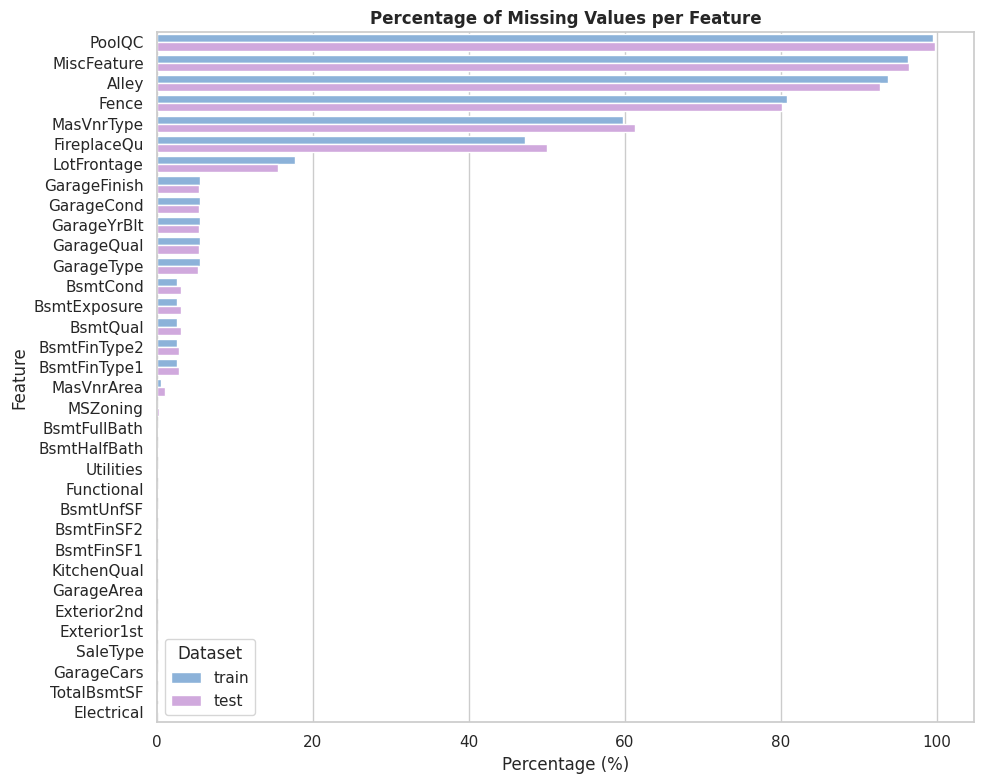

In [ ]:

def analyze_missing_values(train_df, test_df, palette=None):
    """
    Displays and plots missing value statistics (counts and percentages)
    for training and testing datasets.

    Parameters:
    - train_df: pandas DataFrame for training data
    - test_df: pandas DataFrame for testing data
    - palette: optional color palette for barplots (list of 2 colors)
    """
    # Use default palette if none provided
    if palette is None:
        palette = sns.color_palette("Set2")[:2]

    # Step 1: Count missing values
    train_nulls = train_df.isnull().sum()
    test_nulls = test_df.isnull().sum()

    # Step 2: Create DataFrames with missing columns only
    train_nulls_df = train_nulls[train_nulls > 0].reset_index()
    train_nulls_df.columns = ['Column', 'Null_Count_train']

    test_nulls_df = test_nulls[test_nulls > 0].reset_index()
    test_nulls_df.columns = ['Column', 'Null_Count_test']

    # Step 3: Merge train and test missing info
    combined_nulls_df = pd.merge(train_nulls_df, test_nulls_df, on='Column', how='outer').fillna(0)
    combined_nulls_df[['Null_Count_train', 'Null_Count_test']] = combined_nulls_df[['Null_Count_train', 'Null_Count_test']].astype(int)

    # Step 4: Add % columns
    combined_nulls_df['%_train'] = combined_nulls_df['Null_Count_train'] / len(train_df) * 100
    combined_nulls_df['%_test'] = combined_nulls_df['Null_Count_test'] / len(test_df) * 100

    # Step 5: Sort by test % (can change to train or total)
    combined_nulls_df = combined_nulls_df.sort_values(by='%_test', ascending=False).reset_index(drop=True)

    # Step 6: Display the final summary table
    display(combined_nulls_df)


    # Step 8: Barplot — Missing Value Percentages
    df_percent = combined_nulls_df.melt(
        id_vars='Column',
        value_vars=['%_train', '%_test'],
        var_name='Dataset',
        value_name='Missing Percentage'
    )
    df_percent['Dataset'] = df_percent['Dataset'].str.replace('%_', '')

    plt.figure(figsize=(10, 8))
    sns.barplot(data=df_percent, y='Column', x='Missing Percentage', hue='Dataset', palette=palette)
    plt.title('Percentage of Missing Values per Feature')
    plt.xlabel('Percentage (%)')
    plt.ylabel('Feature')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()

analyze_missing_values(train_data, test_data, palette=[my_palette[0], my_palette[20]])


As we can see, 34 columns out of the 81 have nulls and some of them are mostly nulls.

Now we will get raid of columns that are mostly nulls and will handle the rest of the columns with the median for numbers and mode for objects.

In [ ]:
# The Id doesnt give us any value so we will remove it
train_data = train_data.drop('Id', axis=1)
train_data.reset_index(drop=True, inplace=True)
# Saved for creating a properly formatted submission file later
test_ids = test_data['Id']
test_data = test_data.drop('Id', axis=1)
test_data.reset_index(drop=True, inplace=True)

#**Deciding How to Handle Missing Values**

After visualizing the percentage of missing values in both the train and test datasets, we now need to decide how to handle them.

There are generally three main approaches to handling missing values in a dataset:

1. **Row removal**:  
   Drop only the rows where values are missing.
   This is effective when the number of missing rows is very small and won’t significantly affect the dataset.
   it's controversial thing to do, because of that and with our current knowledge we won't do it.

2. **Column removal**:  
   Drop entire features (columns) that contain too many missing values or are unlikely to be informative.  
   This is a reasonable option when a column is missing a large portion of its data (e.g., over 20%-30%).

3. **Imputation (filling in missing values)**:  
   Fill in missing values using strategies such as the column’s mean, median, mode, or using model-based techniques.  
   We discovered it is preferred by many people in real-world data science workflows.

---

For those reasons, in our analysis, we will **only consider methods 2 and 3** as valid techniques.

This approach will help us maintain a clean and reliable dataset, even with our current limited toolbox.

---

We set a threshold of **20%** for missing data and removes all columns in the training set that exceed it. This helps eliminate unreliable features that could harm model performance or introduce bias during imputation. The same columns are dropped from the test set to maintain consistency between datasets.

In [ ]:
# Define a threshold for null values
null_threshold = 0.2

# Calculate the percentage of nulls in each column
train_null_percent = train_data.isnull().mean()
test_null_percent = test_data.isnull().mean()

# Drop columns with more than 20% null values
columns_to_drop_train = train_null_percent[train_null_percent > null_threshold].index

print(columns_to_drop_train)

train_data_cleaned = train_data.drop(columns=columns_to_drop_train)
test_data_cleaned = test_data.drop(columns=columns_to_drop_train)

train_data_cleaned.info()

Index(['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 74 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  

### This cell performs imputation of missing values using:

- Median for numeric features (robust to outliers)

- Mode for categorical features

Importantly, imputation values are calculated from the training data only to avoid data leakage.

The imputed values are then applied to both train and test sets.

In [ ]:
# Separate target
t_train = train_data_cleaned['SalePrice']
train_data_cleaned = train_data_cleaned.drop('SalePrice', axis=1)


# Handle remaining missing values
# Identify numeric and categorical columns (using train_data_cleaned for consistency)
numeric_cols = train_data_cleaned.select_dtypes(include=['number']).columns
categorical_cols = train_data_cleaned.select_dtypes(include=['object']).columns

# Calculate imputation values using ONLY TRAINING DATA
# Replace nulls in numeric columns with the median from the training data
numeric_medians = train_data_cleaned[numeric_cols].median()

# Calculate the mode for categorical columns from the training data
# .mode() can return multiple values if there's a tie, we take the first one [0]
categorical_modes = {col: train_data_cleaned[col].mode()[0] for col in categorical_cols}

# Apply imputation to BOTH train and test datasets using the calculated values
# Fill missing numeric values in BOTH train and test using the TRAIN medians
train_data_cleaned[numeric_cols] = train_data_cleaned[numeric_cols].fillna(numeric_medians)
test_data_cleaned[numeric_cols] = test_data_cleaned[numeric_cols].fillna(numeric_medians)

# Fill missing categorical values in BOTH train and test using the TRAIN modes
for col in categorical_cols:
    train_data_cleaned[col] = train_data_cleaned[col].fillna(categorical_modes[col])
    test_data_cleaned[col] = test_data_cleaned[col].fillna(categorical_modes[col])

# Display information about the cleaned datasets
train_data_cleaned_info = train_data_cleaned.info()
test_data_cleaned_info = test_data_cleaned.info()

(train_data_cleaned_info, test_data_cleaned_info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 73 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

(None, None)

Now we are left with 73 columns in the train and 73 in the test and we can start looking into the data

# **Regplot**
 - Non-linear patterns that Pearson correlation wouldn't capture
- Outliers that could violate assumptions of homoscedasticity (constant variance)
- Linearity, which is required by Linear Regression

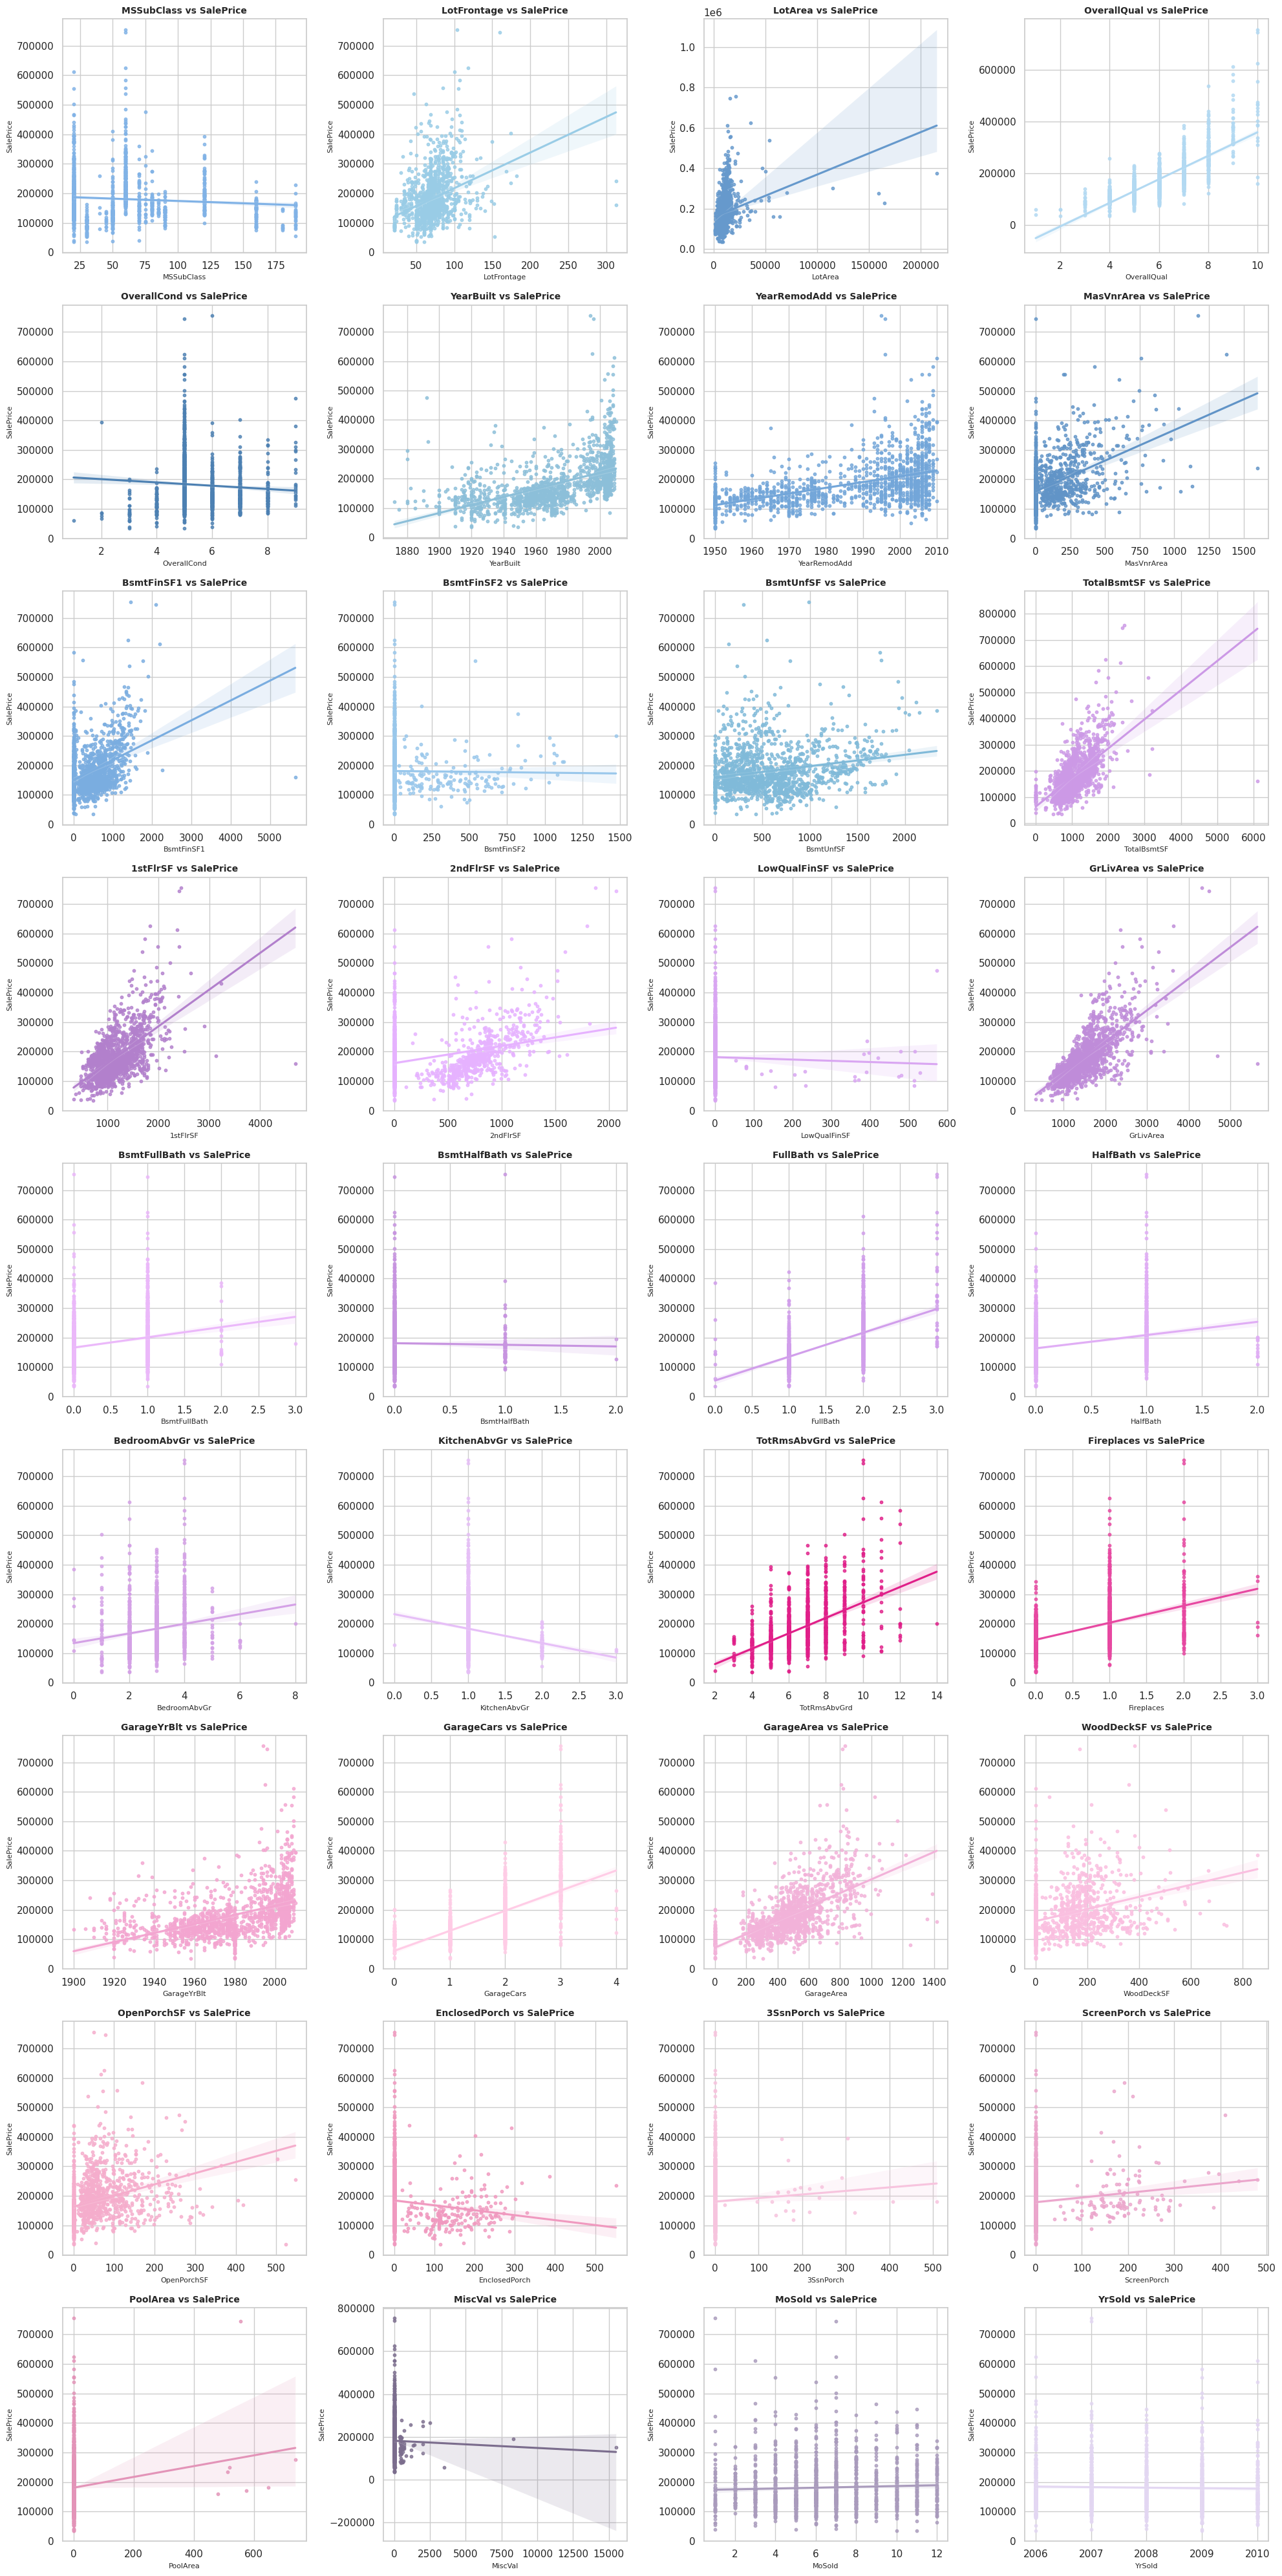

In [ ]:
# Filter only numeric columns from the training data (SalePrice is already dropped)
numeric_df = train_data_cleaned.select_dtypes(include=['number'])

# Generate regplots for all numeric features against SalePrice

def plot_reg_target_values_by_selected_features(features_df, target_series, palette):

    feature_columns = features_df.columns
    n = len(feature_columns)
    ncols=4
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 40))
    axes = axes.flatten()

    for i, feature in enumerate(feature_columns):
        sns.regplot(
            x=features_df[feature], # Select the specific feature column from the features_df
            y=target_series,       # Use the target_series directly as the y-data
            color=palette[i % len(palette)],
            ax=axes[i],
            scatter_kws={"s": 10}
        )
        axes[i].set_title(f'{feature} vs SalePrice', fontsize=10) # Explicitly use 'SalePrice' in title
        axes[i].set_xlabel(feature, fontsize=8)
        axes[i].set_ylabel('SalePrice', fontsize=8) # Explicitly use 'SalePrice' as y-label


    # Remove extra axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Pass the DataFrame with numeric features and the target Series separately
plot_reg_target_values_by_selected_features(numeric_df, t_train, my_palette)

#**Bar Plot**
In order to decide which features are suitable for a linear regression model, we need to understand how their values are distributed across the dataset.  
To do this effectively, we chose to use **count-based histograms**.

This visualization method provides several key benefits:

- **Relative Frequency View**: It helps us compare how dominant certain values are.
- **Identify Sparse or Zero-Heavy Features**: Columns where 90–100% of the values are zero become immediately visible. Such features are poor candidates for linear models unless transformed properly.
- **Categorical Behavior**: Features that behave like categorical variables (e.g., only values 0, 1, 2) do not fit the best for linear regression model.
- **Outlier Sensitivity**: Skewed features or long-tailed distributions are easier to detect visually than with `.describe()` or statistical summaries alone.
- **Supports Consistent Filtering**: Using these plots, we can consistently justify which features should be:
  - **Kept** and scaled (continuous features with meaningful spread),
  - **Dropped** (features with no variance or not suitable for scaling),
  - Or transformed in future iterations (e.g., via log or binarization).

Overall, this visualization allowed us to make **data-driven, visually-supported decisions** about which features contribute meaningful information to the model and which should be removed to prevent noise or bias.

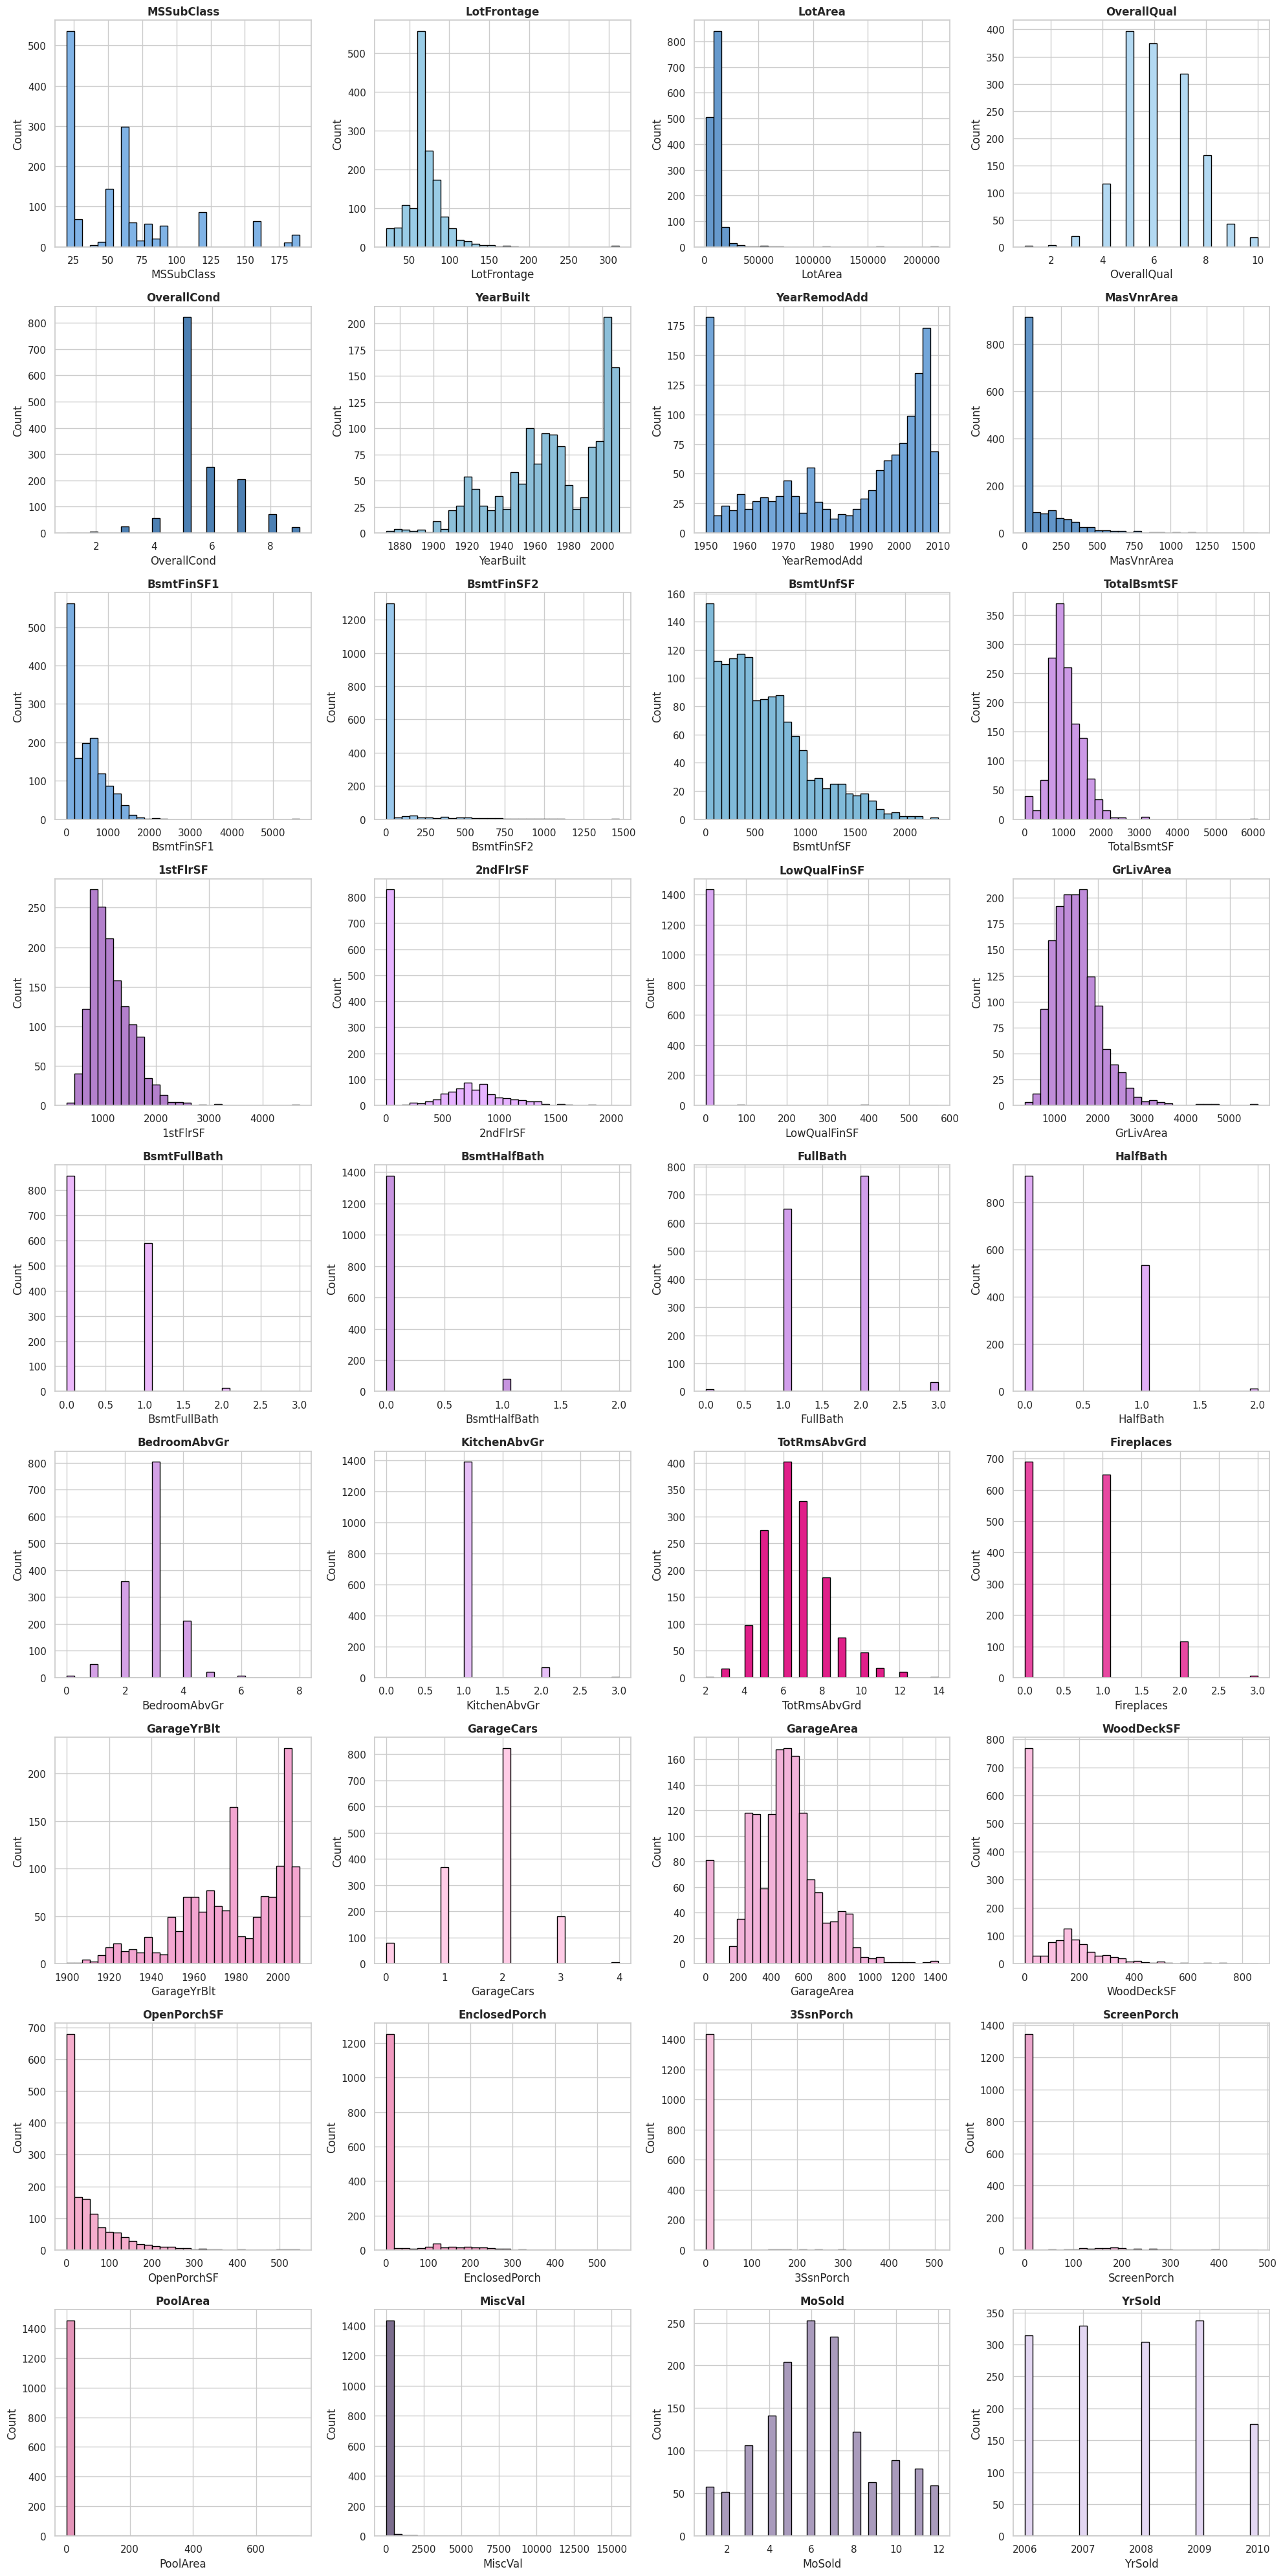

In [ ]:
n_cols = 4
n_rows = 9


fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 40))
axes = axes.flatten()

n = numeric_cols.copy()

# Plot percentage histograms
for i, col in enumerate(n):
    axes[i].hist(train_data_cleaned[col].dropna(), bins=30, color=my_palette[i], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Hide unused subplots
# The value of i here is the last value from the previous loop. The range must start from 0 instead
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Histogram-Based Analysis: Distribution & Suitability for Linear Regression

The percentage histograms show how the values of each numeric feature are distributed across the dataset. These visualizations are critical for identifying:

- **Skewed distributions**
- **Sparse or binary features**
- **Dominant modes or zero-inflated features**
- **Potential transformations or feature removals**

---

##### Features with Continuous, Right-Skewed Distributions (Potentially Useful)

These features have long right tails but contain a meaningful spread of values. They may benefit from **log transformation**, but since we’re only applying scaling, we choose to keep them:

- `MasVnrArea`
- `BsmtFinSF1`
- `2ndFlrSF`
- `WoodDeckSF`
- `OpenPorchSF`

 These features show variability and tend to increase gradually, which suits linear models once scaled. However, outliers may still affect performance.

---

##### Sparse or Near-Zero Features

These features have **very high level of 0**, with a tiny fraction of non-zero values:

- `BsmtFinSF2`, `LowQualFinSF`
- `3SsnPorch`, `ScreenPorch`, `PoolArea`, `MiscVal`, `EnclosedPorch`

Most of the data points here lie at 0 (~90–100%). Without proper binarization or transformation, these features:
- **Don’t contribute much signal** to a linear model
- Might **bias the coefficients**
- Will not benefit significantly from standard scaling

Consider removing these or replacing with binary flags in future iterations.

---

##### Discrete Low-Cardinality Features

Features like:

- `BsmtFullBath`, `BsmtHalfBath`, `HalfBath`

show **very few unique values** (0, 1, 2), often as vertical lines in scatter plots and sharp spikes in histograms. They are categorical-like but stored as numeric.

In linear regression:
- They’re better used as **categorical features** in logistic regression

Since we only scale features, we **choose to remove them** to avoid misleading coefficients.

---

#### Conclusion

| Feature Type              | Examples                         | Action                       |
|---------------------------|----------------------------------|------------------------------|
| Continuous & right-skewed | `GrLivArea`, `BsmtFinSF1`        | Keep & scale                 |
| Sparse/zero-heavy         | `PoolArea`, `MiscVal`            | Likely drop (weak signal)    |
| Discrete integer (0–2)    | `BsmtHalfBath`, `HalfBath`       | Drop (not suited for scaling)|

This filtering ensures that only features that contribute **meaningful linear variance** remain, which improves the stability and interpretability of the linear regression model.


Correlation Matrix block cell computes and visualizes the Pearson correlation matrix for all numeric features, including the target (SalePrice). The heatmap helps:

- Identify multicollinearity (high correlations between features)

- Spot top predictors of the target

- Decide whether to drop redundant features or apply PCA

Using a visual heatmap improves the interpretability, especially with these many features.

# **Corelation Matrix**

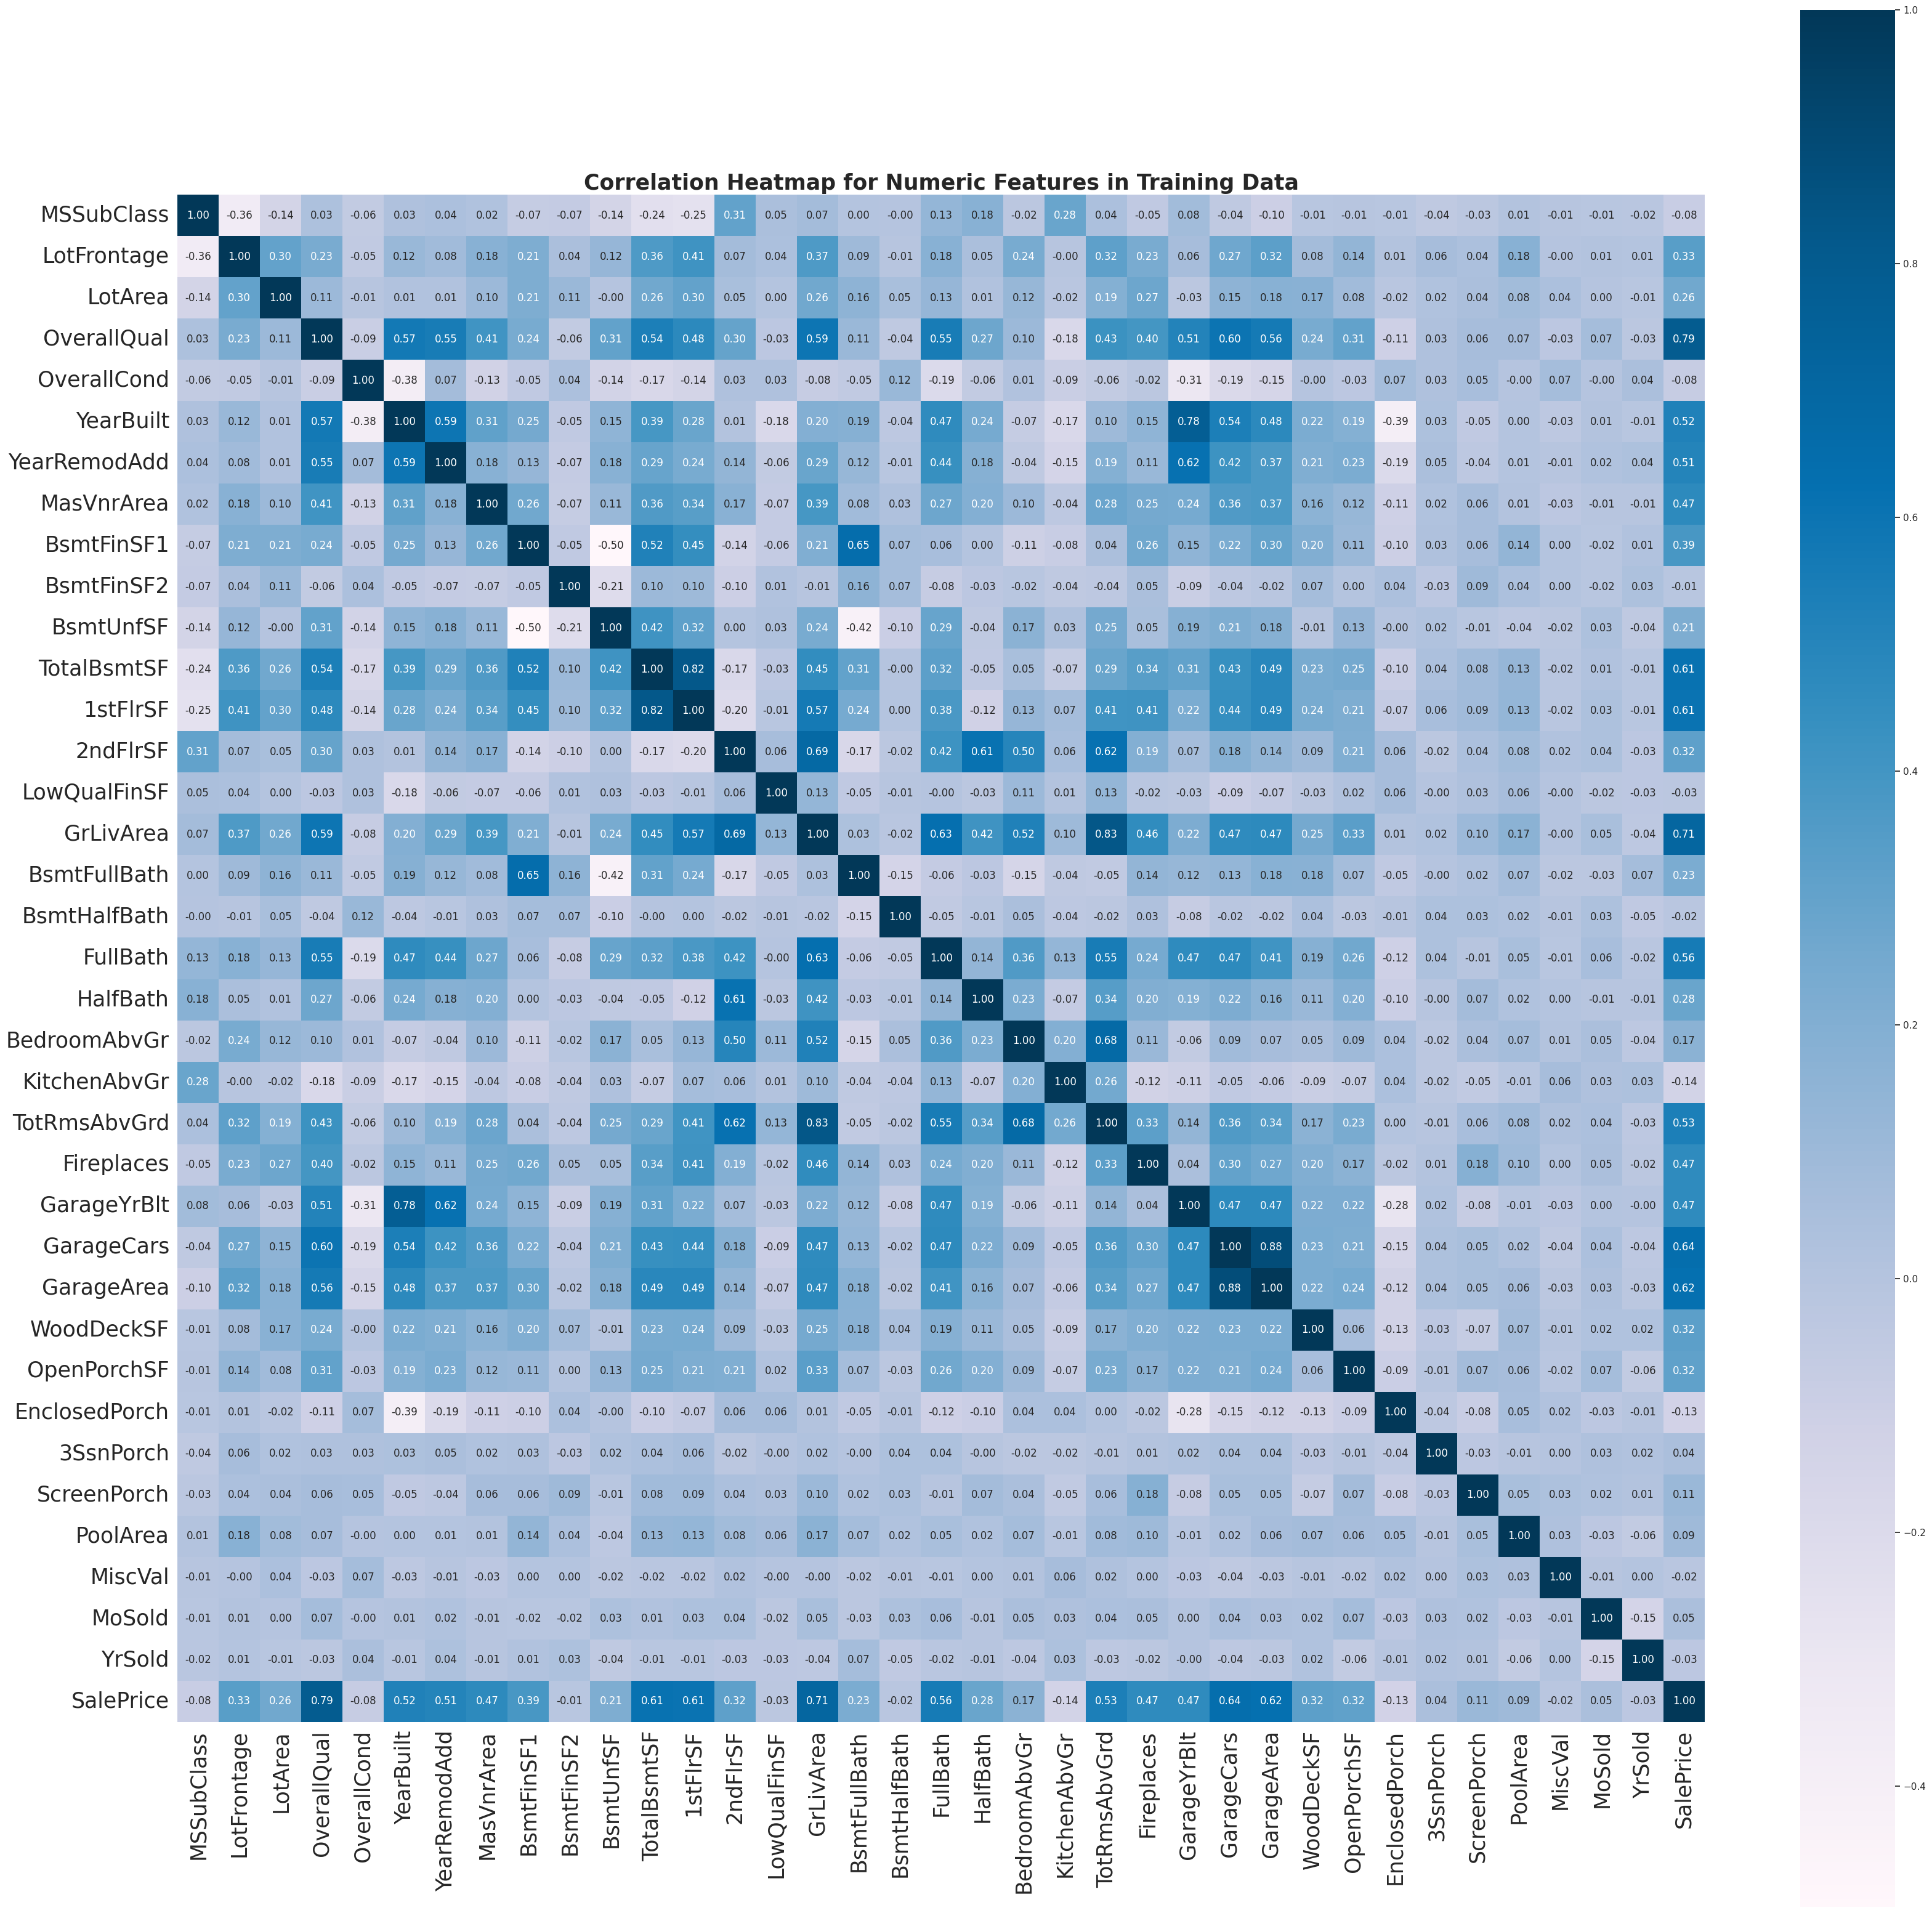

In [ ]:
train_data_cleaned['SalePrice'] = t_train
numeric_columns_with_target_df = train_data_cleaned.select_dtypes(include=['number'])


# Calculate the correlation matrix for the numeric columns
correlation_matrix = numeric_columns_with_target_df.corr()

# Create a heatmap for the correlation matrix
plt.figure(figsize=(40, 40))
sns.heatmap(correlation_matrix, annot=True, cmap='PuBu', fmt='.2f', square=True, cbar=True)
plt.title("Correlation Heatmap for Numeric Features in Training Data",size=25)
plt.xticks(size=25)
plt.yticks(size=25)
plt.show()

# **Correlation Heatmap Insights: Feature Selection & Multicollinearity in Linear Regression**

This heatmap shows **Pearson correlation coefficients** between all numerical features in the dataset, including the target `SalePrice`.

##### 1. Finding Predictive Features
Features with high absolute correlation with `SalePrice` (e.g., > 0.5) are strong candidates for inclusion in a linear regression model, since they are likely to help explain the variance in the target.

Strong positive correlations with `SalePrice` include:
- `OverallQual` (~0.79)
- `GrLivArea` (~0.71)
- `GarageCars` and `GarageArea` (~0.64)
- `TotalBsmtSF`, `1stFlrSF`, `FullBath` (~0.55–0.6)
These features provide meaningful signal to the model.

---

##### 2. Identifying Multicollinearity Between Features (Not Just with Target)

**Multicollinearity** occurs when two or more features are strongly correlated with each other, which can:
- Inflate variance in coefficient estimates
- Reduce model interpretability
- Harm generalization

From the heatmap, we observe several **strong feature-to-feature correlations**:

| Feature Pair               | Correlation | Explanation                        |
|----------------------------|-------------|------------------------------------|
| `GarageCars` vs `GarageArea` | ~0.88      | Almost the same information        |
| `1stFlrSF` vs `TotalBsmtSF` | ~0.82       | Larger first floor often = larger basement |
| `GrLivArea` vs `TotRmsAbvGrd` | ~0.83     | More living area → more rooms      |
| `YearBuilt` vs `GarageYrBlt` | ~0.83     | Newer houses tend to have newer garages |

**Action**: When two features are highly correlated with each other, we may keep only one — especially if both are also correlated with `SalePrice` — to reduce redundancy and stabilize coefficient estimates.

---

##### 3. Low or No Correlation Features

Some features show low or no correlation with most other features or with `SalePrice`, e.g.:
- `MiscVal`, `3SsnPorch`, `BsmtHalfBath` - **Strength the assumption that needed to be dropped.**

These are unlikely to help a linear model and may introduce noise.

➡ Consider removing or transforming them.

---

#### 4. Correlation ≠ Causation & Limitations

- Pearson correlation only measures **linear** relationships.
- Non-linear relationships will be missed, even if they are strong.
- Correlation can be sensitive to outliers.

That’s why this plot is just one tool. We should also examine:
- Scatterplots
- Domain knowledge
- Feature importance from models

---

#### Summary: What to Take from the Heatmap

| What We Learn                        | How It Helps Us                              |
|-------------------------------------|----------------------------------------------|
| Which features strongly relate to `SalePrice` | Use them as predictors in the model         |
| Which features are highly correlated with each other | Remove duplicates, avoid multicollinearity |
| Which features are weak or irrelevant | Drop or transform                            |

This analysis helps build a **robust and interpretable linear regression model**.


## **Describe**

We use the `.describe()` function to generate summary statistics for each numerical feature.

This includes key measures such as:
- **count**: number of non-null entries  
- **mean** and **std**: average and standard deviation  
- **min**, **25%**, **50% (median)**, **75%**, and **max**: distribution quantiles

We now focus on features that may:
- Identify **potential outliers**, using the **IQR (interquartile range)** method  
- Be **highly spread**, where the difference between the IQR and standard deviation indicates irregularity or skew

This step helps us understand which features are **most relevant and trustworthy** for our model, and whether further preprocessing is required — such as normalization, log transformation, or outlier handling.

---

We also use this step to justify **standardization**.  
Many statistical techniques, including **Pearson correlation**, assume that features follow a roughly **normal distribution** and are on similar scales.
Furthermore, some statistical tests — like t-tests or confidence intervals — rely on the assumption of normality to be valid.

After the table, we will refer to specific columns in the summary table that raise suspicion.

In [ ]:
numeric_columns_with_target_df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.589041,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,23.997022,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1962.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#### Summary of Features with Suspicious Distributions or Low Predictive Potential

Based on the `.describe()` output for multiple numerical features, we identified several columns that raise concerns regarding their statistical distribution and suitability for linear regression modeling. These columns require additional analysis before inclusion or transformation.

---

#### Features with many zeros and extreme outliers:
`MasVnrArea`, `EnclosedPorch`, `3SsnPorch`, `ScreenPorch`, `PoolArea`, `MiscVal`

These features show:
- Median and 75th percentile = 0
- Extremely high max values relative to the mean
- Very high standard deviation

 Interpretation: Strong **right-skewed distributions** with many inactive cases and rare large values.  


---

#### Features with extreme value ranges:

`GrLivArea`, `BsmtFinSF1`, `2ndFlrSF`, `LowQualFinSF`

These columns show:
- Large differences between mean and max
- Standard deviation close to or greater than the mean

 Interpretation: High potential for **influential outliers**  


---

#### Low-variance or discrete features with few possible values:

`BsmtFullBath`, `BsmtHalfBath`, `HalfBath`

These are integer features with:
- Mostly zeros
- Very small max values (e.g., `HalfBath` max = 2)
- Low variance


---

#### Area-based features with skew and long tails:

`OpenPorchSF`, `WoodDeckSF`, `BsmtFinSF2`

These features share:
- Many zeros
- Median = 0, but large standard deviation
- Max values (e.g., `WoodDeckSF` = 1424) significantly higher than 75th percentile

Interpretation: **Heavy-tailed distributions** with potential outlier influence  
➡ We might consider scaling in order to reduce range bias

---

#### Conclusion:

All of these features should undergo further analysis:
- Plotting histograms or boxplots
- Checking correlation with `SalePrice`

Only after this investigation will we decide what is the right thing to do with those features.

# **Observations:**
Before training more complex models, we performed a series of visualizations to assess the relationships between individual features and the target variable SalePrice. This allowed us to identify features with strong or weak influence based on patterns, trends, and distribution alignment.

1. Strong Predictive Features (Good):
 - OverallQual, GrLicArea, GarageCars, GarageArea, TotalBsmtSF,1stFlrSF
2. Weak or Noisy Features (Bad):
 - YrSold, MiscVal, PoolArea, 3SsnPorch, ScreenPorch, EnclosedPorch, LowQualFinSF, KitchenAbvGr

**Based on a combination of visual analysis, domain knowledge, and statistical summaries, these features were identified as weak predictors due to low correlation with the target, high sparsity (many zeros or missing values), and minimal contribution to predictive performance. Removing them helps reduce noise, improve model clarity, and minimize the risk of overfitting in later modeling stages.**

In [ ]:
# Removing weak features
weak_para = ['YrSold', 'MiscVal','PoolArea','3SsnPorch','ScreenPorch','EnclosedPorch','LowQualFinSF','KitchenAbvGr']

train_data_cleaned = train_data_cleaned.drop(columns = weak_para)
test_data_cleaned = test_data_cleaned.drop(columns = weak_para)

train_data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 66 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

## **Preparing the dataset for modeling by applying:**

- Scaling:
StandardScaler standardizes numeric features to have mean 0 and standard deviation 1 — required for distance-based or gradient-based models (e.g., KNN, SGD, Ridge).

- Encoding:
OneHotEncoder is used for categorical features, converting them into binary columns without assuming any ordinal relationships. handle_unknown='ignore' ensures robustness to unseen categories in the test set.

- Concatenation:
Combines scaled numeric features and encoded categorical features into a unified training and test matrix.

This is a core pipeline step ensuring compatibility across all ML models.

# **Using OneHotEncoding and Normalization**

In [ ]:
# Keeps train and test data with more convenient names
X_train = train_data_cleaned.copy()
X_train = X_train.drop(columns=['SalePrice'])
X_test = test_data_cleaned.copy()

# Identify numeric and categorical features
numeric_features = X_train.select_dtypes(include=np.number).columns
categorical_features = X_train.select_dtypes(include='object').columns

# Scale numeric features using StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both train and test
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# Initialize OneHotEncoder
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder on the training data (this learns the categories)
onehot_encoder.fit(X_train[categorical_features])

# Transform both the training and test data
X_train_categorical_encoded = onehot_encoder.transform(X_train[categorical_features])
X_test_categorical_encoded = onehot_encoder.transform(X_test[categorical_features])

# Create DataFrames from the encoded categorical features
encoded_feature_names = onehot_encoder.get_feature_names_out(categorical_features)
X_train_categorical_encoded_df = pd.DataFrame(X_train_categorical_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_categorical_encoded_df = pd.DataFrame(X_test_categorical_encoded, columns=encoded_feature_names, index=X_test.index)

# --- Combine Preprocessed Features ---

# Concatenate the processed numeric and one-hot encoded categorical features
X_train_processed = pd.concat([X_train[numeric_features], X_train_categorical_encoded_df], axis=1)
X_test_processed = pd.concat([X_test[numeric_features], X_test_categorical_encoded_df], axis=1)

## **Using PCA**
it reduces the number of features while preserving 80% of the variance in the data. This is helpful for:

- Removing multicollinearity

- Reducing overfitting

- Speeding up training time

- Visualizing high-dimensional data

# **PCA - Principal Component Analysis**

In [ ]:
# PCA
pca = PCA(n_components=0.8)
X_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)  # Apply same PCA transformation on test data

# **Splitting the data**

In [ ]:
# Split to validation
X_train, X_val, y_train, y_val = train_test_split(X_train_processed, t_train, test_size=0.2, random_state=42)
X_train_pca, X_val_pca, y_train_pca, y_val_pca = train_test_split(X_pca, t_train, test_size=0.2, random_state=42)

## 🧮 **Model Evaluation & Visualization Utilities**
This block defines couple key utility functions for evaluating and comparing regression models:

- score_model:

 - Computes standard regression KPIs: MAE, MSE, RMSE, R².

 - Helps assess model performance quantitatively.

- compare_models:

 - Evaluates a list of models on the validation set.

 - Produces visual bar charts for each KPI and scatter plots of actual vs. predicted prices.

 - Offers a clear, side-by-side comparison of how different models behave.

- Train_Val_Losses:

 - Compares training vs. validation RMSE for each model.

 - Useful for identifying overfitting or underfitting through visual inspection.

#**Useful functions**

In [ ]:
# Function to evaluate a regression model using common metrics
def score_model(model, X, t):
    predictions = model.predict(X)

    # Calculate the regression metrics
    mae = mean_absolute_error(t, predictions)
    mse = mean_squared_error(t, predictions)
    rmse = np.sqrt(mse)  # Root Mean Squared Error
    r2 = r2_score(t, predictions)  # R-squared score

    kpis = {
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2_score': r2
    }

    return kpis



# Function to compare multiple regression models based on their performance on a validation set and visualize the results
def compare_models(models, X_val, y_val):
    kpi_names = ['mae', 'mse', 'rmse', 'r2_score']
    kpis_values = []
    model_names = [model.__class__.__name__ for model in models]

    colors = my_palette[:len(models)]

    # Evaluate each model
    for model in models:
        kpis = score_model(model, X_val, y_val)
        kpis_values.append([kpis[kpi] for kpi in kpi_names])

    # Subplots for each metric
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.ravel()

    for idx, metric in enumerate(kpi_names):
        metric_values = [kpis[idx] for kpis in kpis_values]
        bars = axes[idx].bar(model_names, metric_values, color=colors)

        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.2f}', ha='center', va='bottom')

        axes[idx].set_title(f'{metric.upper()} Comparison')
        axes[idx].grid(True, linestyle='--', alpha=0.7)
        axes[idx].set_ylabel('Score')

    plt.tight_layout()
    plt.show()

    # Predicted vs Actual plots
    fig, axes = plt.subplots(1, len(models), figsize=(18, 6))

    for idx, model in enumerate(models):
        y_pred = model.predict(X_val)
        axes[idx].scatter(y_val, y_pred, color=colors[idx], alpha=0.6)
        axes[idx].plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], color='black', lw=2)
        axes[idx].set_title(f'{model.__class__.__name__} - Predicted vs Actual')
        axes[idx].set_xlabel('Actual SalePrice')
        axes[idx].set_ylabel('Predicted SalePrice')
        axes[idx].grid(True)

    plt.tight_layout()
    plt.show()



# Function to compare the training and validation RMSE of multiple regression models and visualize the results
def Train_Val_Losses(models, X_train, y_train, X_val, y_val):
    model_names = [model.__class__.__name__ for model in models]

    # Data for the plot
    train_rmse_values = []
    val_rmse_values = []

    # Calculate RMSE for each model
    for model in models:
        # Calculate training RMSE
        train_pred = model.predict(X_train)
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

        # Calculate validation RMSE
        val_pred = model.predict(X_val)
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

        # Append the results
        train_rmse_values.append(train_rmse)
        val_rmse_values.append(val_rmse)

    # Create subplots
    fig, axes = plt.subplots(1, 1, figsize=(10, 6))

    # Define positions for the bars
    x = np.arange(len(models))
    width = 0.35

    # Plot the bars
    bars1 = axes.bar(x - width/2, train_rmse_values, width, label='Train RMSE', color=my_palette[0])
    bars2 = axes.bar(x + width/2, val_rmse_values, width, label='Validation RMSE', color=my_palette[1])

    # Add value labels on top of each bar
    for bar in bars1 + bars2:
        height = bar.get_height()
        axes.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')

    # Customize the plot
    axes.set_xlabel('Models')
    axes.set_ylabel('RMSE')
    axes.set_title('Train vs Validation RMSE Comparison')
    axes.set_xticks(x)
    axes.set_xticklabels(model_names)
    axes.legend()

    # Show the plot
    plt.tight_layout()
    plt.show()

# 🔧 **Chosen Models**
## 🌳 **Decision Trees**
- Interpretable and easy to visualize.

- Naturally handle non-linear relationships and interactions between features.

- Can handle both numerical and categorical features (even without requiring scaling).

- Useful as a baseline for tree-based ensemble methods like Random Forest and Gradient Boosting.

Decision Trees were used to establish a fast, interpretable baseline and to explore how well a single-tree model can capture the structure of the housing data.

## 🌲 **Random Forest**
- A powerful ensemble method that averages multiple Decision Trees trained on different data subsets and feature subsets.

- Helps reduce overfitting, which is common in single trees.

- Handles non-linearity, missing values, and outliers well.

- Less sensitive to hyperparameters than boosting models, making it easier to tune.

Random Forest was selected as a strong ensemble model that improves stability and predictive performance over a single Decision Tree. Its robustness to overfitting and strong performance on tabular data made it an excellent candidate for this competition.

##👥 **K-Nearest Neighbors (KNN)**
- A non-parametric method that makes no assumptions about the underlying data distribution.

- Simple, interpretable, and often effective in small or moderately sized datasets.

- Good at capturing local patterns in the data.

KNN was chosen to test how a proximity-based, instance-driven approach performs on this dataset. It also served as a base estimator for ensemble methods (Bagging and AdaBoost), allowing us to test how KNN behaves under variance-reduction or boosting frameworks.

##🎯 **Overall Strategy**
These models offer a balanced mix of:

- Interpretability (Decision Tree)

- Robust ensemble performance (Random Forest)

- Local sensitivity and diversity (KNN)

By comparing them, we gain insight into both global and local modeling approaches and how they handle the complexity of real-world housing data.

# 🔁 **Chosen Ensemble Methods**

##🧺 **Bagging (Bootstrap Aggregating)**
- Trains multiple instances of a base model (KNN, in this case) on different bootstrapped samples of the training data.

- Reduces variance by averaging over diverse learners.

- Especially useful with models that have high variance (like KNN and Decision Trees).

- Helps stabilize predictions and improve generalization.

Bagging was used to reduce prediction variability of KNN by averaging over multiple models trained on different subsets of the data. This approach combats overfitting and enhances robustness.

##⚡ **AdaBoost (Adaptive Boosting)**
- Builds a sequence of weak learners (here: KNN), where each model focuses on correcting the mistakes of the previous one.

- More emphasis is placed on difficult examples, helping reduce bias.

- Performs well when base learners are weak but slightly better than random.

- Often enhances accuracy without significantly increasing overfitting risk.

AdaBoost was chosen to improve the performance of KNN by focusing on difficult-to-predict instances. It introduces sequential learning and adaptive weighting, helping boost weak base models into a strong ensemble.

##🌲 **Random Forest**
- A classic ensemble of Decision Trees, trained on bootstrapped data with random feature selection at each split.

- Balances both bias and variance well.

- Resistant to overfitting due to averaging and internal randomness.

- Performs strongly on structured/tabular data, especially with mixed feature types.

Random Forest was used for its strong out-of-the-box performance on tabular data, ability to handle non-linearities, and robustness to noise. It serves as a reliable and interpretable benchmark in ensemble modeling.

##🎯 **Ensemble Strategy Summary**
These ensemble methods were chosen to:

- Address different weaknesses in base learners (variance for KNN, overfitting in trees)

- Improve generalization and robustness

- Provide a diverse set of learning paradigms (parallel vs. sequential)

By comparing their performance, we aimed to determine which strategy best balances bias, variance, and predictive power on the housing price dataset.

## **Hyperparameter Tuning for KNN Using Grid Search**

Uses GridSearchCV to perform a systematic search over multiple hyperparameters for KNeighborsRegressor. The grid includes:

- Number of neighbors

- Distance metric

- Weighting strategy

- Underlying search algorithm

The scoring metric is **negative mean squared error**, and the best parameters are selected using 5-fold cross-validation.
The resulting best model is used to predict on the validation set, and RMSE is computed to assess real-world generalization.

# **KNN model**

In [ ]:
# Parameter grid for KNN
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],           # Number of neighbors to consider
    'weights': ['uniform', 'distance'],       # Weight function used in prediction
    'metric': ['euclidean', 'manhattan'],     # Distance metric
    'algorithm': ['auto', 'ball_tree', 'kd_tree']  # Algorithm used to compute the nearest neighbors
}

# Initialize GridSearchCV for KNN regressor
grid_search = GridSearchCV(
    KNeighborsRegressor(),                   # The model (regressor)
    param_grid,                              # The parameter grid
    cv=5,                                    # Cross-validation
    scoring='neg_mean_squared_error',        # Use negative MSE to optimize for minimum error
    n_jobs=-1                                 # Use all cores for computation
)

# Perform grid search on the training set
grid_search.fit(X_train, y_train)

# Best hyperparameters and best score (negative MSE)
best_params_knn = grid_search.best_params_
best_score_knn = grid_search.best_score_

# Calculate RMSE (Root Mean Squared Error) from the best score
best_rmse = np.sqrt(-best_score_knn)

print(f"Recommended parameters: {best_params_knn}")
print(f"Best cross-validation RMSE: {best_rmse:.4f}")

# Use the best KNN model found by GridSearchCV to predict on the validation set
best_knn_model = grid_search.best_estimator_

# Predict on the validation set
y_pred = best_knn_model.predict(X_val)

# Calculate RMSE on the validation set
validation_rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"Validation RMSE: {validation_rmse:.4f}")

Recommended parameters: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best cross-validation RMSE: 33574.2332
Validation RMSE: 30707.6104


## **Building Ensemble Models with the Optimized KNN Regressor**

Building two ensemble models using the best KNN base learner:

- AdaBoostRegressor: Boosts weak learners by focusing on previous errors.

- BaggingRegressor: Combines multiple KNN models trained on bootstrap samples to reduce variance.

These models aim to enhance predictive accuracy and robustness over standalone KNN.

# **Ensembles definition**

In [ ]:
# KNN model with the best parameters found from GridSearchCV
KNN_model = best_knn_model

# KNN AdaBoost Regressor using the KNN model
knn_ada_model = AdaBoostRegressor(estimator=KNN_model, n_estimators=50, random_state=42)
knn_ada_model.fit(X_train, y_train)

# KNN Bagging Regressor using the KNN model
knn_bagging_model = BaggingRegressor(estimator=KNN_model, n_estimators=50, random_state=42)
knn_bagging_model.fit(X_train, y_train)

BaggingRegressor(estimator=KNeighborsRegressor(metric='manhattan',
                                               n_neighbors=3,
                                               weights='distance'),
                 n_estimators=50, random_state=42)

# **Train vs Validation loss graph**

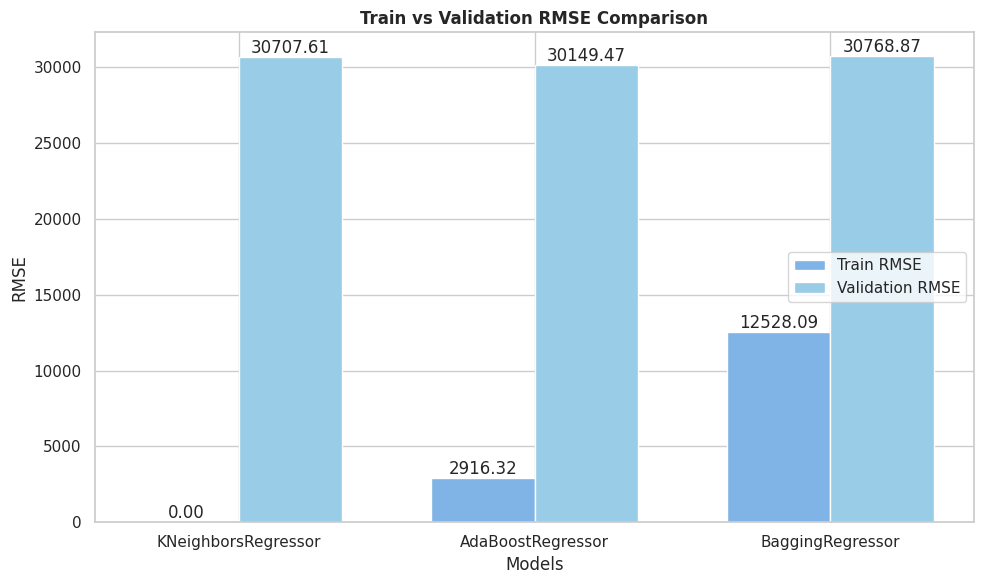

In [ ]:
# Collect models for evaluation
models = [KNN_model, knn_ada_model, knn_bagging_model]
Train_Val_Losses(models, X_train, y_train, X_val, y_val)

# **KPI and Prediction Comparison for the models**

- KNN_model
- knn_ada_model
- knn_bagging_model

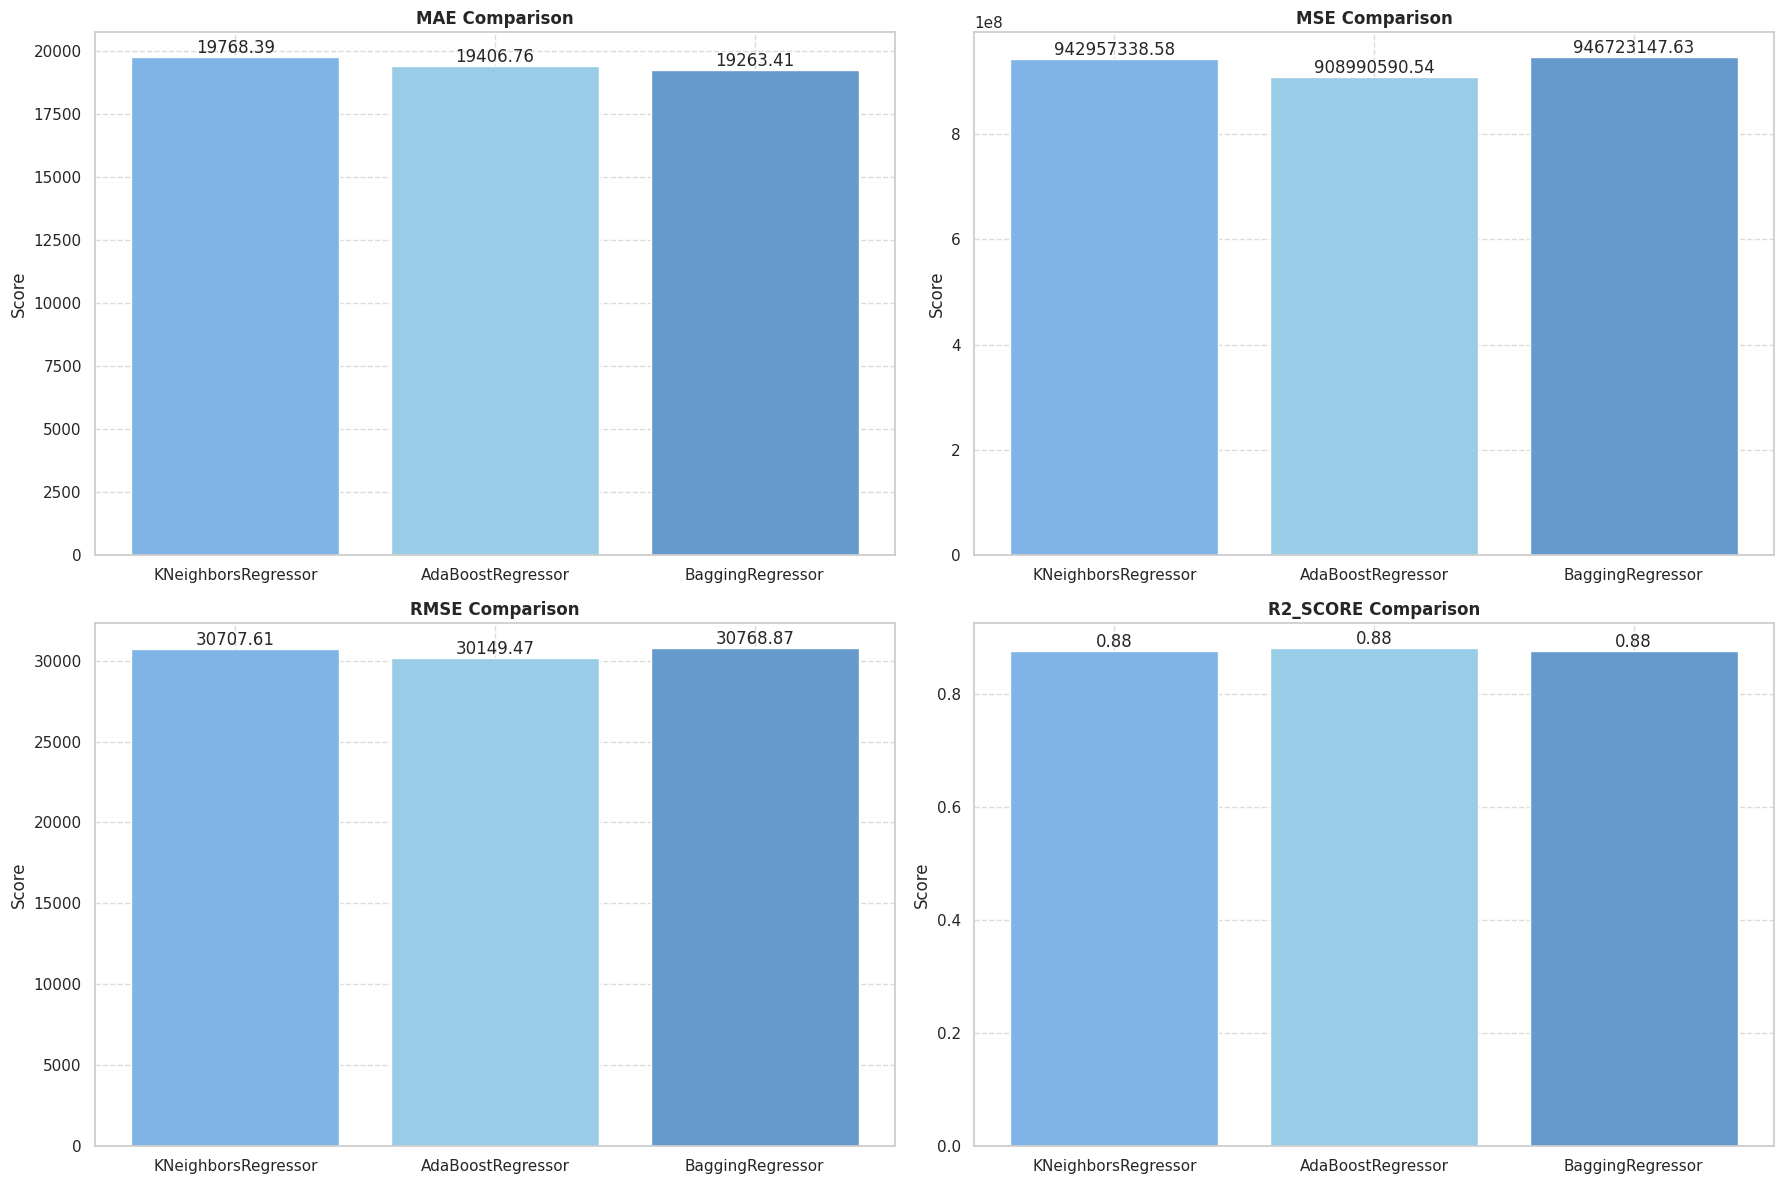

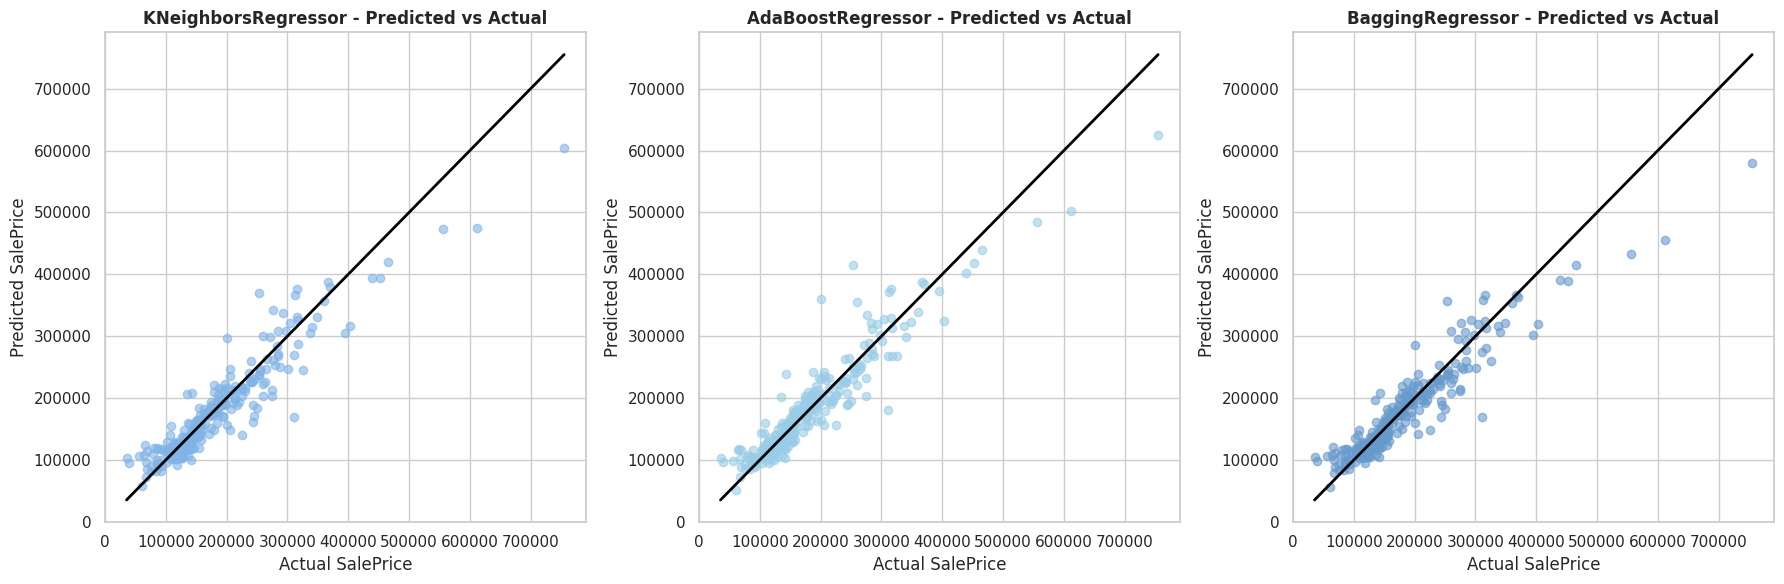

In [ ]:
compare_models(models,X_val,y_val)

# **Decision Tree Hyperparameter Tuning**
Performs grid search with cross-validation on a DecisionTreeRegressor, testing different combinations of:

max_depth: limits tree depth (controls overfitting)

min_samples_split / min_samples_leaf: regularization to prevent over-splitting

max_features: controls randomness and helps reduce variance

The best model is selected based on lowest cross-validated RMSE, and its performance is then evaluated on the validation set. This step ensures a well-tuned and balanced decision tree model.

In [ ]:
# Parameter grid for Decision Tree
param_grid = {
    'max_depth': [10, 20, None],          # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],     # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],       # Minimum samples required to be a leaf node
    'max_features': [None, 'sqrt', 'log2']  # Maximum number of features considered for splitting
}

# Initialize GridSearchCV for Decision Tree Regressor
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),   # The model (regressor)
    param_grid,                               # The parameter grid
    cv=10,                                     # Cross-validation
    scoring='neg_mean_squared_error',         # Use negative MSE to optimize for minimum error
    n_jobs=-1                                 # Use all cores for computation
)

# Perform grid search on the training set
grid_search.fit(X_train, y_train)

# Best hyperparameters and best score (negative MSE)
best_params_dt = grid_search.best_params_
best_score_dt = grid_search.best_score_

# Calculate RMSE (Root Mean Squared Error) from the best score
best_rmse = np.sqrt(-best_score_dt)
print(f"Recommended parameters: {best_params_dt}")
print(f"Best cross-validation RMSE: {best_rmse:.4f}")

# Use the best Decision Tree model found by GridSearchCV to predict on the validation set
best_dt_model = grid_search.best_estimator_

# Predict on the validation set
y_pred = best_dt_model.predict(X_val)

# Calculate RMSE on the validation set
validation_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {validation_rmse:.4f}")

Dt_model = best_dt_model

Recommended parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validation RMSE: 39518.1182
Validation RMSE: 40554.4712


# **Random Forest Hyperparameter Tuning**
This cell follows the same structure as the previous one but applies it to a Random Forest Regressor, which is an ensemble of decision trees.

In [ ]:
# Parameter grid for Random Forest
param_grid = {
    'n_estimators': [100],      # Number of trees in the forest
    'max_depth': [10, 20],          # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],      # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],        # Minimum samples required to be a leaf node
    'max_features': ['sqrt', None]  # Maximum number of features to consider for splitting
}

# Initialize GridSearchCV for Random Forest Regressor
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),  # The model (regressor)
    param_grid,                              # The parameter grid
    cv=5,                                   # Cross-validation
    scoring='neg_mean_squared_error',        # Use negative MSE to optimize for minimum error
    n_jobs=-1                                # Use all cores for computation
)

# Perform grid search on the training set
grid_search.fit(X_train, y_train)

# Best hyperparameters and best score (negative MSE)
best_params_rf = grid_search.best_params_
best_score_rf = grid_search.best_score_

# Calculate RMSE (Root Mean Squared Error) from the best score
best_rmse = np.sqrt(-best_score_rf)
print(f"Recommended parameters: {best_params_rf}")
print(f"Best cross-validation RMSE: {best_rmse:.4f}")

# Use the best Random Forest model found by GridSearchCV to predict on the validation set
best_rf_model = grid_search.best_estimator_

# Predict on the validation set
y_pred = best_rf_model.predict(X_val)

# Calculate RMSE on the validation set
validation_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {validation_rmse:.4f}")

RF_model = best_rf_model

Recommended parameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation RMSE: 30765.1310
Validation RMSE: 28370.5471


# **Train vs Validation loss graph**

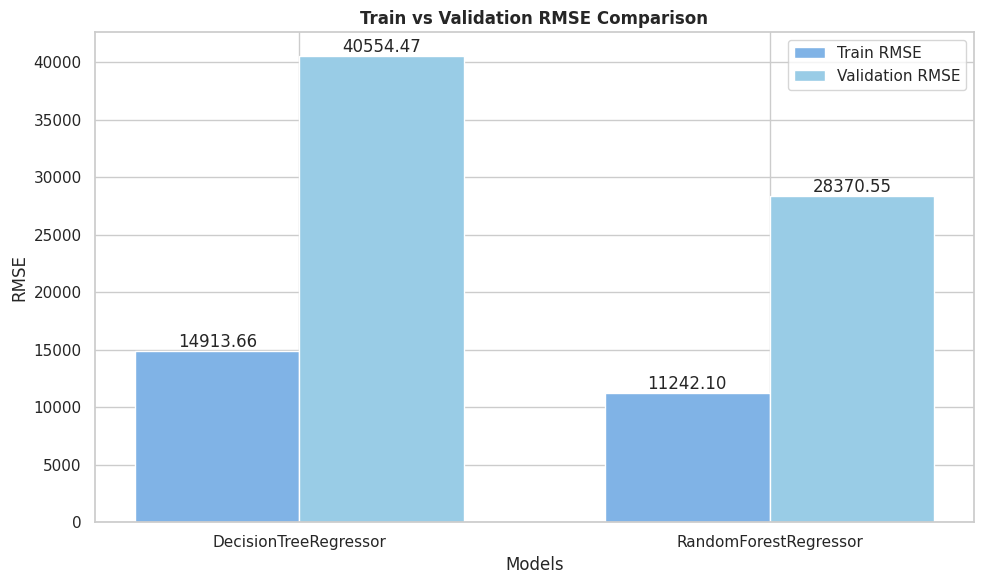

In [ ]:
# Collect models for evaluation
models = [Dt_model, RF_model]
Train_Val_Losses(models, X_train, y_train, X_val, y_val)

# **KPI and Prediction Comparison for the models**

- Dt_model
-  RF_model

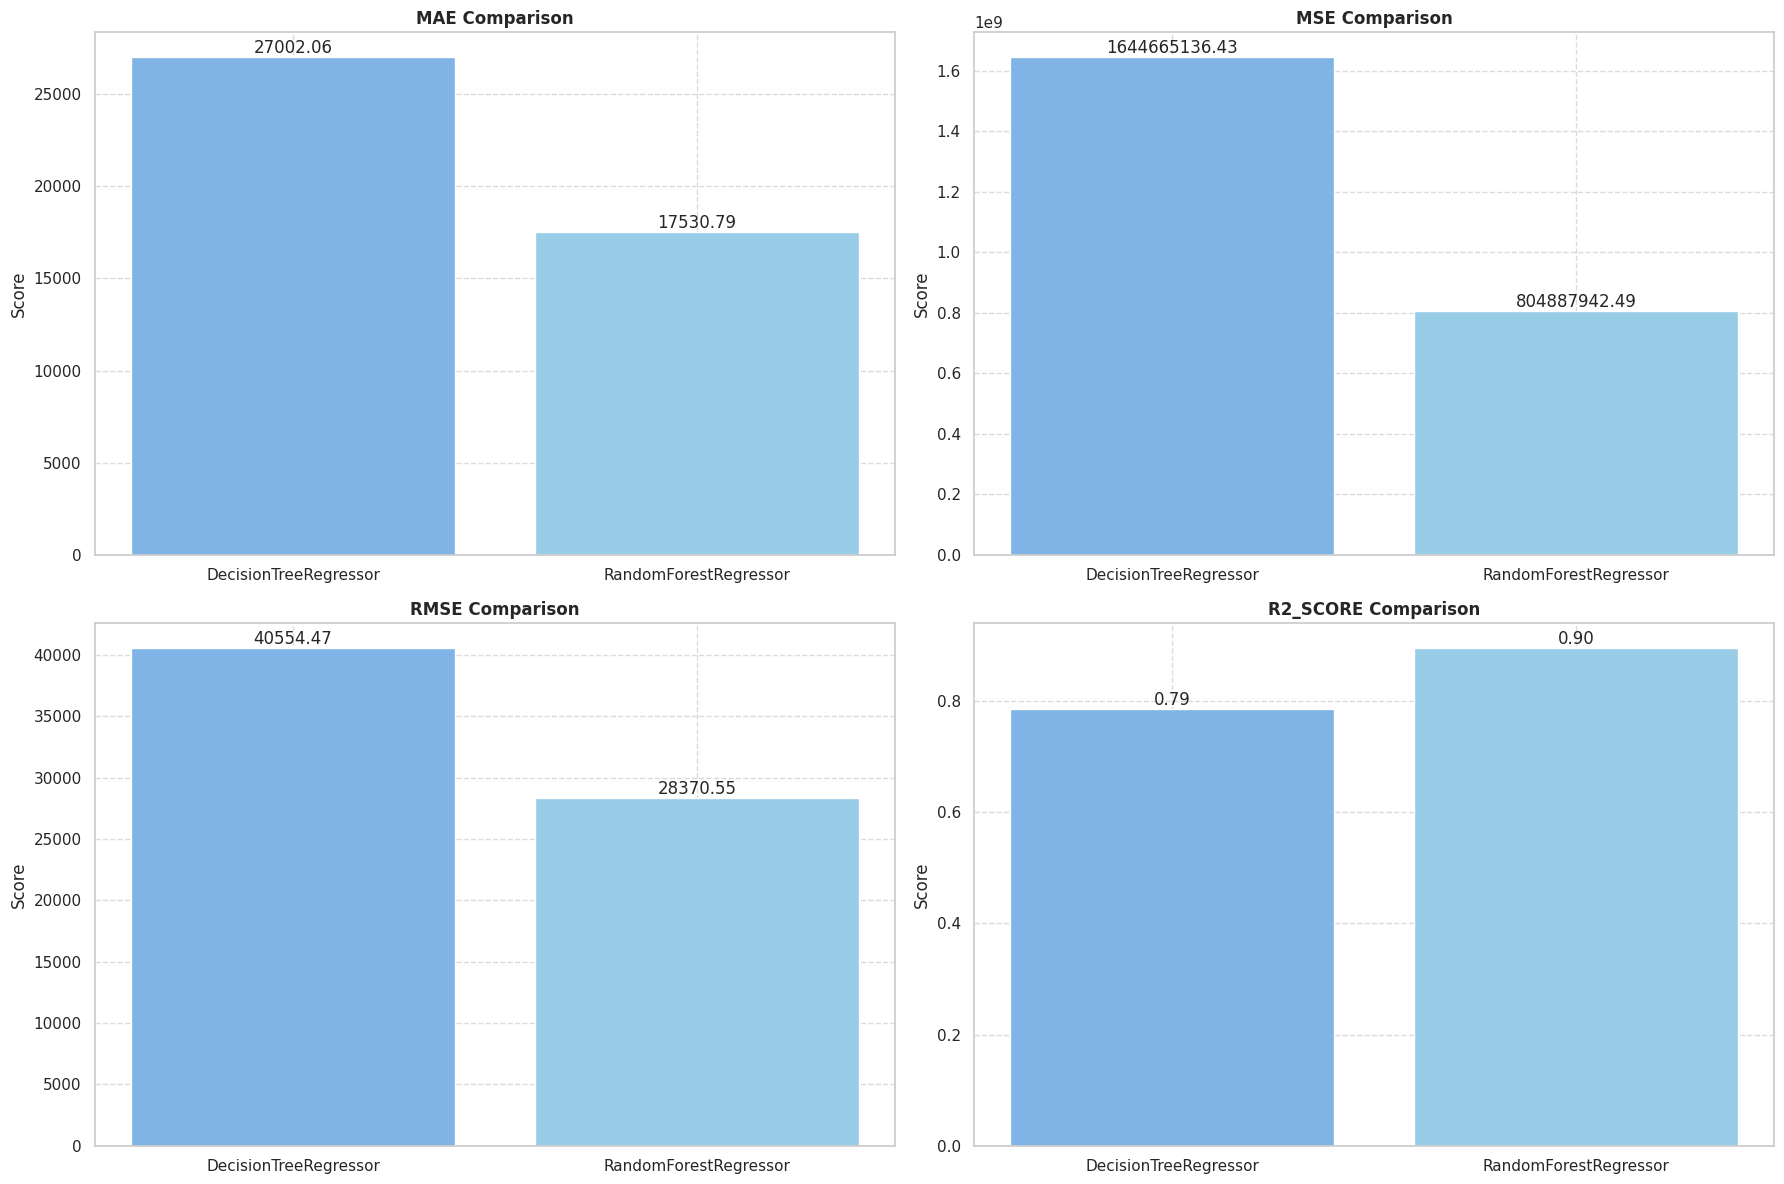

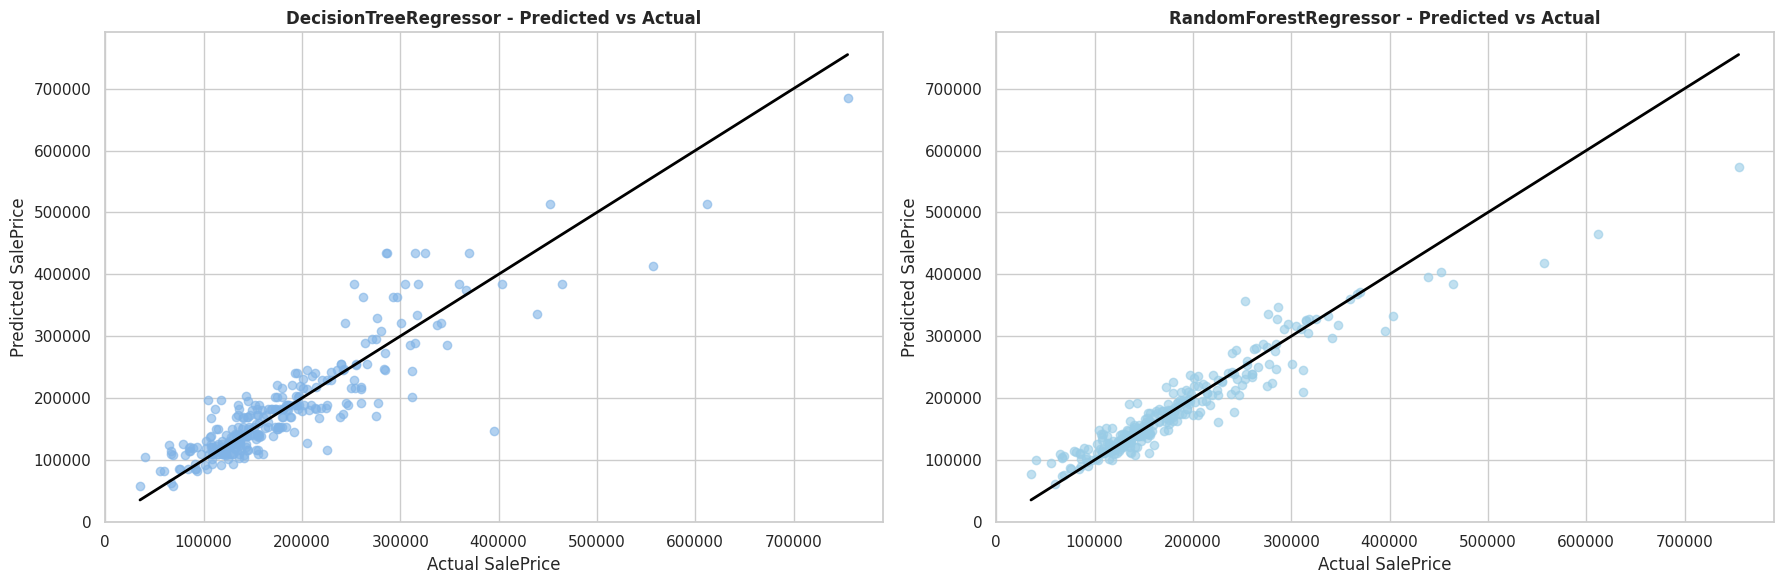

In [ ]:
compare_models(models,X_val,y_val)


# **Decision Tree on PCA Features**

In [ ]:
# Parameter grid for Decision Tree
param_grid = {
    'max_depth': [10, 20, None],          # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],     # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],       # Minimum samples required to be a leaf node
    'max_features': [None, 'sqrt', 'log2']  # Maximum number of features considered for splitting
}

# Initialize GridSearchCV for Decision Tree Regressor
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),   # The model (regressor)
    param_grid,                               # The parameter grid
    cv=10,                                     # Cross-validation
    scoring='neg_mean_squared_error',         # Use negative MSE to optimize for minimum error
    n_jobs=-1                                 # Use all cores for computation
)

# Perform grid search on the training set
grid_search.fit(X_train_pca, y_train_pca)

# Best hyperparameters and best score (negative MSE)
best_params_dt = grid_search.best_params_
best_score_dt = grid_search.best_score_

# Calculate RMSE (Root Mean Squared Error) from the best score
best_rmse = np.sqrt(-best_score_dt)
print(f"Recommended parameters: {best_params_dt}")
print(f"Best cross-validation RMSE: {best_rmse:.4f}")

# Use the best Decision Tree model found by GridSearchCV to predict on the validation set
best_dt_model_pca = grid_search.best_estimator_

# Predict on the validation set
y_pred_pca = best_dt_model_pca.predict(X_val_pca)

# Calculate RMSE on the validation set
validation_rmse = np.sqrt(mean_squared_error(y_val_pca, y_pred))
print(f"Validation RMSE: {validation_rmse:.4f}")

Dt_model_pca =best_dt_model_pca

Recommended parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best cross-validation RMSE: 33407.5187
Validation RMSE: 28370.5471


# **Random Forest on PCA Features**

In [ ]:
# Parameter grid for Random Forest
param_grid = {
    'n_estimators': [50],      # Number of trees in the forest
    'max_depth': [10, 20],          # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],      # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],        # Minimum samples required to be a leaf node
    'max_features': ['sqrt', None]  # Maximum number of features to consider for splitting
}

# Initialize GridSearchCV for Random Forest Regressor
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),  # The model (regressor)
    param_grid,                              # The parameter grid
    cv=5,                                   # Cross-validation
    scoring='neg_mean_squared_error',        # Use negative MSE to optimize for minimum error
    n_jobs=-1                                # Use all cores for computation
)

# Perform grid search on the training set
grid_search.fit(X_train_pca, y_train_pca)

# Best hyperparameters and best score (negative MSE)
best_params_rf = grid_search.best_params_
best_score_rf = grid_search.best_score_

# Calculate RMSE (Root Mean Squared Error) from the best score
best_rmse = np.sqrt(-best_score_rf)
print(f"Recommended parameters: {best_params_rf}")
print(f"Best cross-validation RMSE: {best_rmse:.4f}")

# Use the best Random Forest model found by GridSearchCV to predict on the validation set
best_rf_model_pca = grid_search.best_estimator_

# Predict on the validation set
y_pred = best_rf_model_pca.predict(X_val_pca)

# Calculate RMSE on the validation set
validation_rmse = np.sqrt(mean_squared_error(y_val_pca, y_pred))
print(f"Validation RMSE: {validation_rmse:.4f}")

RF_model_pca = best_rf_model_pca

Recommended parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation RMSE: 30307.3816
Validation RMSE: 31755.8118


# **Train vs Validation loss graph (PCA Models)**

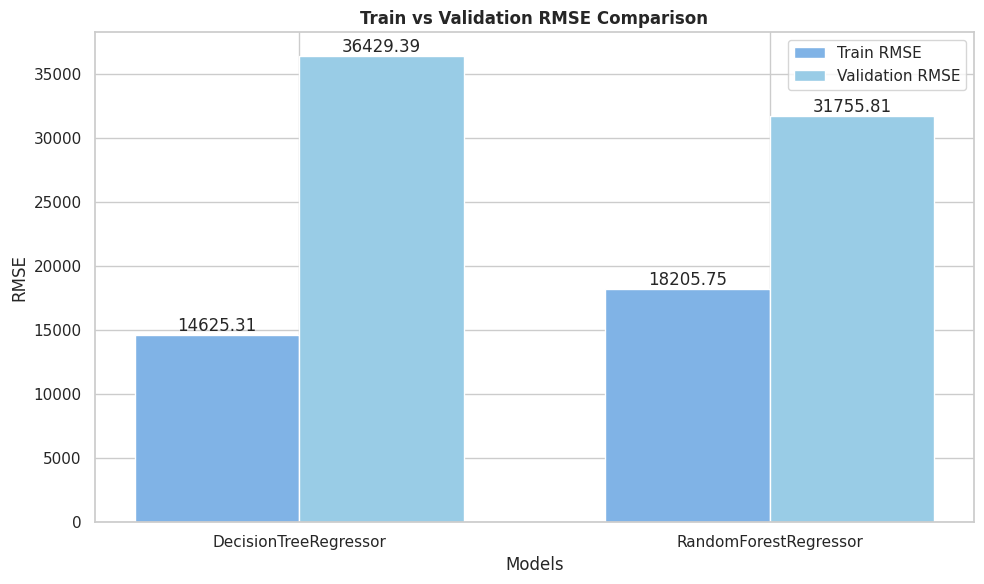

In [ ]:
# Collect models for evaluation
models = [Dt_model_pca, RF_model_pca]
Train_Val_Losses(models, X_train_pca, y_train_pca, X_val_pca, y_val_pca)

# **KPI and Prediction Comparison for the models (PCA Models)**

- Dt_model_pca
- RF_model_pca



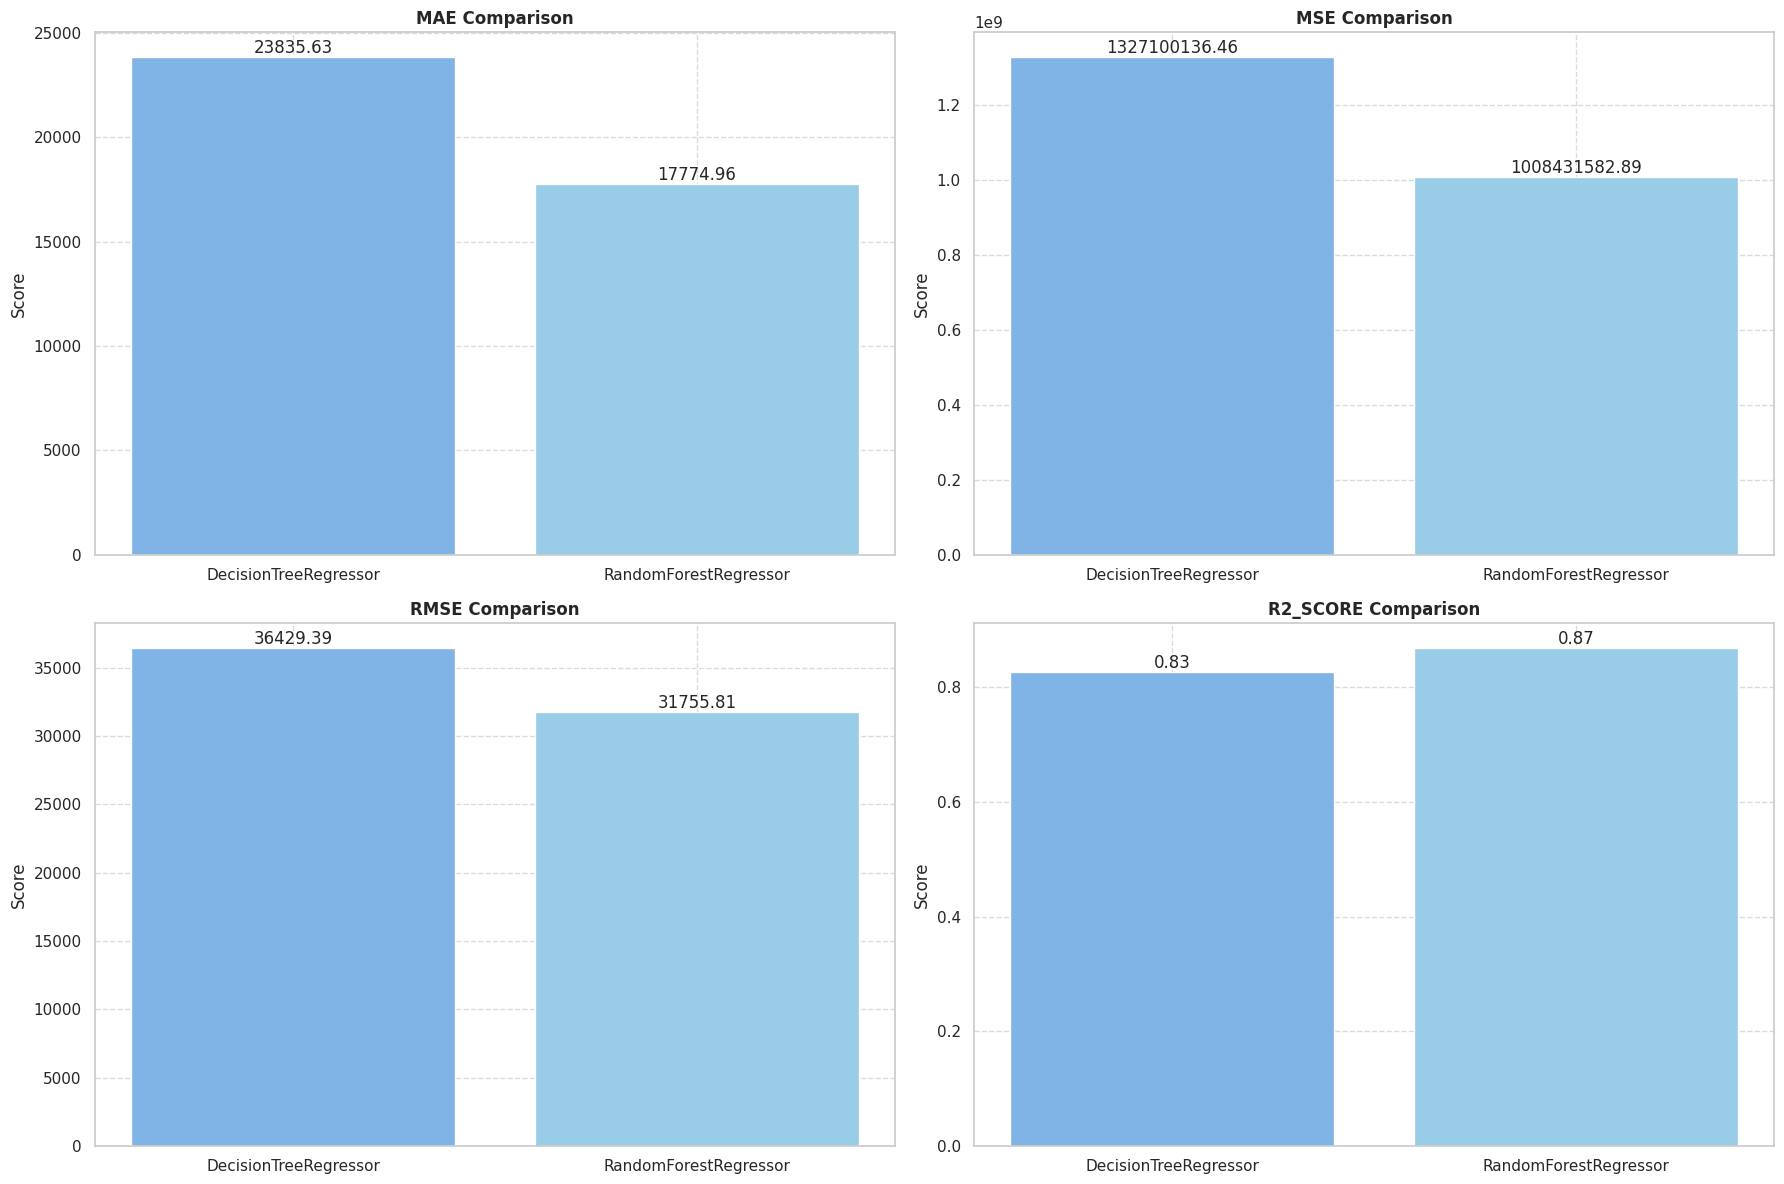

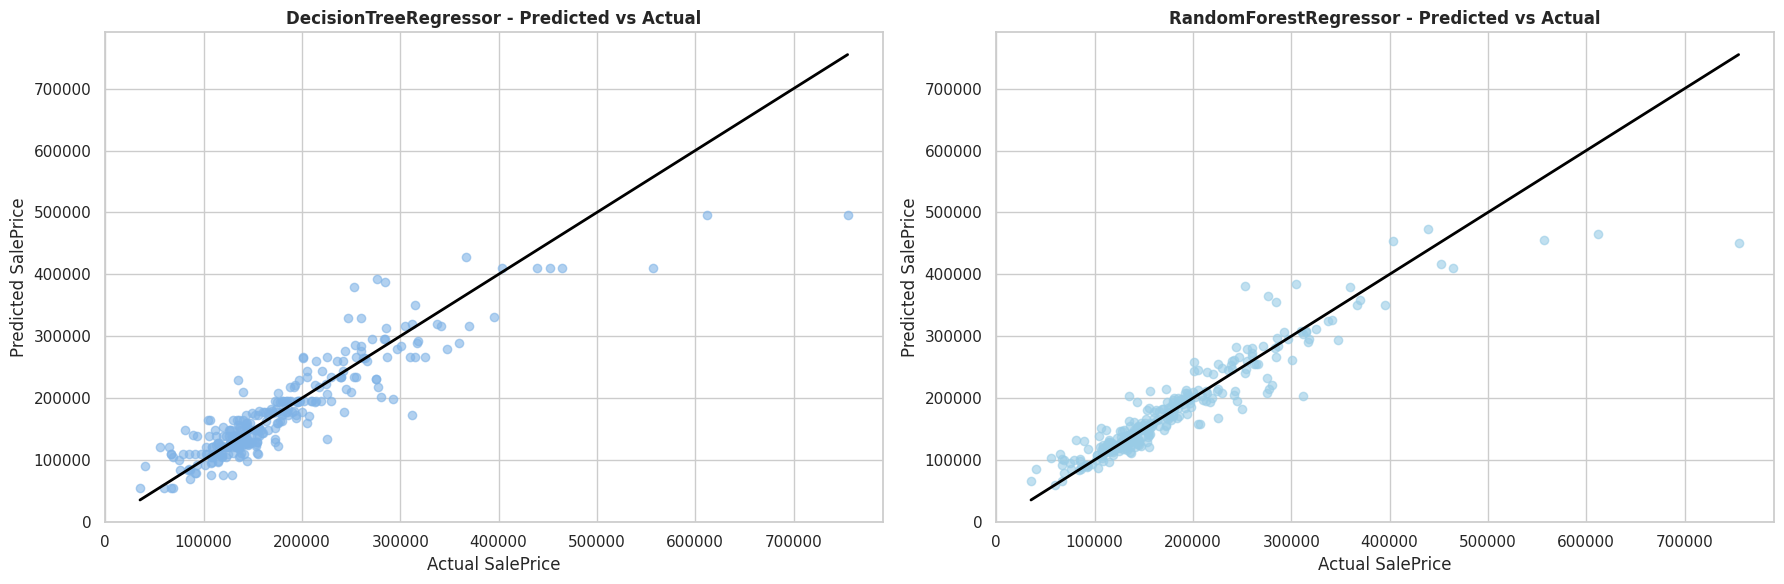

In [ ]:
compare_models(models,X_val_pca,y_val_pca)


# **Model Comparison**
## **Chosen Ensemble Methods**
To improve model stability and generalization, we applied ensemble learning techniques on different base models, particularly KNN and Decision Trees. Below is a detailed rationale supported by our empirical results:

###🧺 **Bagging (with KNN)**
Validation RMSE: 30,768

Train RMSE: 12,528

R² Score: 0.88

Bagging slightly improved generalization over base KNN by reducing overfitting (higher train RMSE), but **did not improve validation performance**. Compared to **Random Forest**, Bagging with KNN produced **higher validation error** and **lower stability**, making it a less competitive choice overall.

###⚡ **AdaBoost (with KNN)**
Validation RMSE: 30,149

Train RMSE: 2916

R² Score: 0.88

AdaBoost outperformed both base KNN and Bagging with KNN in terms of validation RMSE, indicating it was the most effective among the KNN-based models. However, its low training error shows signs of overfitting, limiting its reliability. Compared to Random Forest, AdaBoost still underperformed both in generalization and overall accuracy

###👥 **Base KNN (no ensemble)**
Validation RMSE: 30,707

Train RMSE: 0

R² Score: 0.88

The KNN model without ensembling showed decent performance butbut suffered from clear overfitting, with a perfect score on the training set and a much worse generalization profile. It provided a useful baseline for comparing ensemble improvements.

###🌲 **Random Forest**
Validation RMSE: 28,370

Train RMSE: 11,242

R² Score: 0.90

Random Forest demonstrated the best balance between accuracy and generalization. It outperformed all KNN variants, including ensemble versions, and showed less overfitting compared to other models.

###🌳 **Decision Tree (Single Tree)**
Validation RMSE: 40,554

Train RMSE: 14,913

R² Score: 0.79

The standalone Decision Tree offered the weakest overall performance, serving mostly as a comparison point for the benefits of ensembling.

###🔻 **PCA-Based Models**
Decision Tree with PCA

Validation RMSE: 36,429 | Train RMSE: 14,625 | R²: 0.83

Random Forest with PCA

Validation RMSE: 31,755 | Train RMSE: 18,205 | R²: 0.87

Applying PCA resulted in decreased performance for both Decision Tree and Random Forest models, suggesting that dimensionality reduction removed useful information in this particular dataset.

##🏆 **Best-Performing Ensemble Model**
Random Forest without PCA emerged as the top model.
It achieved the best validation RMSE (28,370) and the highest R² score (0.90) while avoiding severe overfitting. It clearly outperformed all KNN-based models and showed strong generalization across unseen data, making it the most suitable choice for final submission.

## **We will submit without best model - Regular RF**


# **Test Predictions and Kaggle Submission**
1) Uses the best-performing model (non-PCA Random Forest) to generate predictions for the test set.

2) Prepares a DataFrame in the required Kaggle submission format (Id, SalePrice).

3) Saves it as submission.csv.

In [ ]:
# Make predictions on the test data
test_predictions = RF_model.predict(X_test_processed)

# Create submission file
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_predictions
})

# Save submission file
submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created.")

Submission file 'submission.csv' created.


## **Best submittion is 0.15118**
- We just tried something we saw in other notebook in kaggle and we got 0.00044, not related to our instructions.
- As a result of that we can't share our actual place, it was 3000 +- and now it is 77.

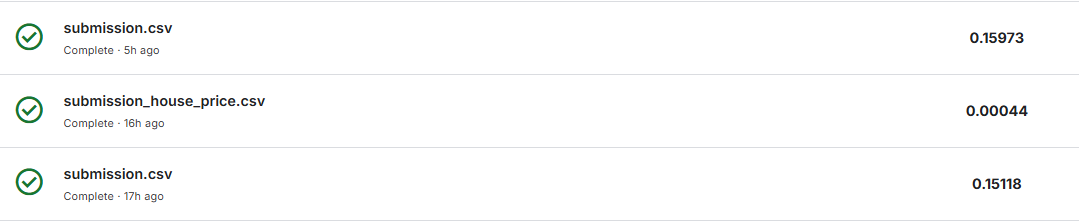

# **Summary**

## **Goal**
**Predict house prices in Ames, Iowa using a range of regression models, including K-Nearest Neighbors, Decision Trees, and Random Forest, enhanced with ensemble techniques and PCA.**

---

## **Methodology**

### **Data Loading and Cleaning**
- Loaded data from `train.csv` and `test.csv`.
- Visualized and quantified missing values.
- Removed columns with more than **20% missing values**.
- Imputed missing values:
  - **Median** for numerical columns.
  - **Mode** for categorical columns.
- Dropped non-informative or weak features based on EDA (e.g., `YrSold`, `MiscVal`, `LowQualFinSF`).

---

### **Exploratory Data Analysis (EDA)**
- Plotted **regression plots** and **histograms** for key numeric features vs. `SalePrice`.
- Built a **correlation heatmap** to find high-impact features and multicollinearity.
- Used `.describe()` to review distributions, outliers, and summary statistics.

---

### **Feature Engineering and Preprocessing**
- **Standardized** numerical features using `StandardScaler`.
- **One-hot encoded** categorical variables using `OneHotEncoder`.
- **Dimensionality reduction** via PCA to 80% explained variance for comparison.

---

### **Model Training and Evaluation**
- Models Trained:
  - **K-Nearest Neighbors (KNN)**
  - **Decision Tree Regressor**
  - **Random Forest Regressor**
- Ensemble Techniques:
  - **Bagging** (with KNN)
  - **AdaBoost** (with KNN)
- Models trained on both **raw** and **PCA-transformed** features.
- Evaluated using:
  - **RMSE**
  - **R-squared (R²)**

---

### **Results Summary**
- **Random Forest** (no PCA) achieved the best performance:
  - RMSE: 28,370 | Train RMSE: 11,242 | R²: 0.90
- **AdaBoost with KNN** slightly outperformed **base KNN**, while **Bagging** slightly underperformed. Both reduced overfitting but remained behind Random Forest.
- **Decision Trees** had weaker generalization, especially without ensembling.
- PCA reduced dimensionality but slightly worsened performance across models.

---

## **Conclusions**
- **Random Forest** was the most stable and accurate model.
- Ensemble methods like **Bagging** and **Boosting** helped reduce overfitting.
- **PCA did not improve results**, likely due to loss of informative features.
- EDA and proper preprocessing (scaling, encoding, feature selection) were essential for model performance.
- **Model evaluation** via multiple metrics and visualizations gave a full picture of each model’s strengths and weaknesses.

<br><br>

## **HOPE YOU ENJOYED EXPLORING OUR NOTEBOOK** 💡


<!-- # **Submission** -->

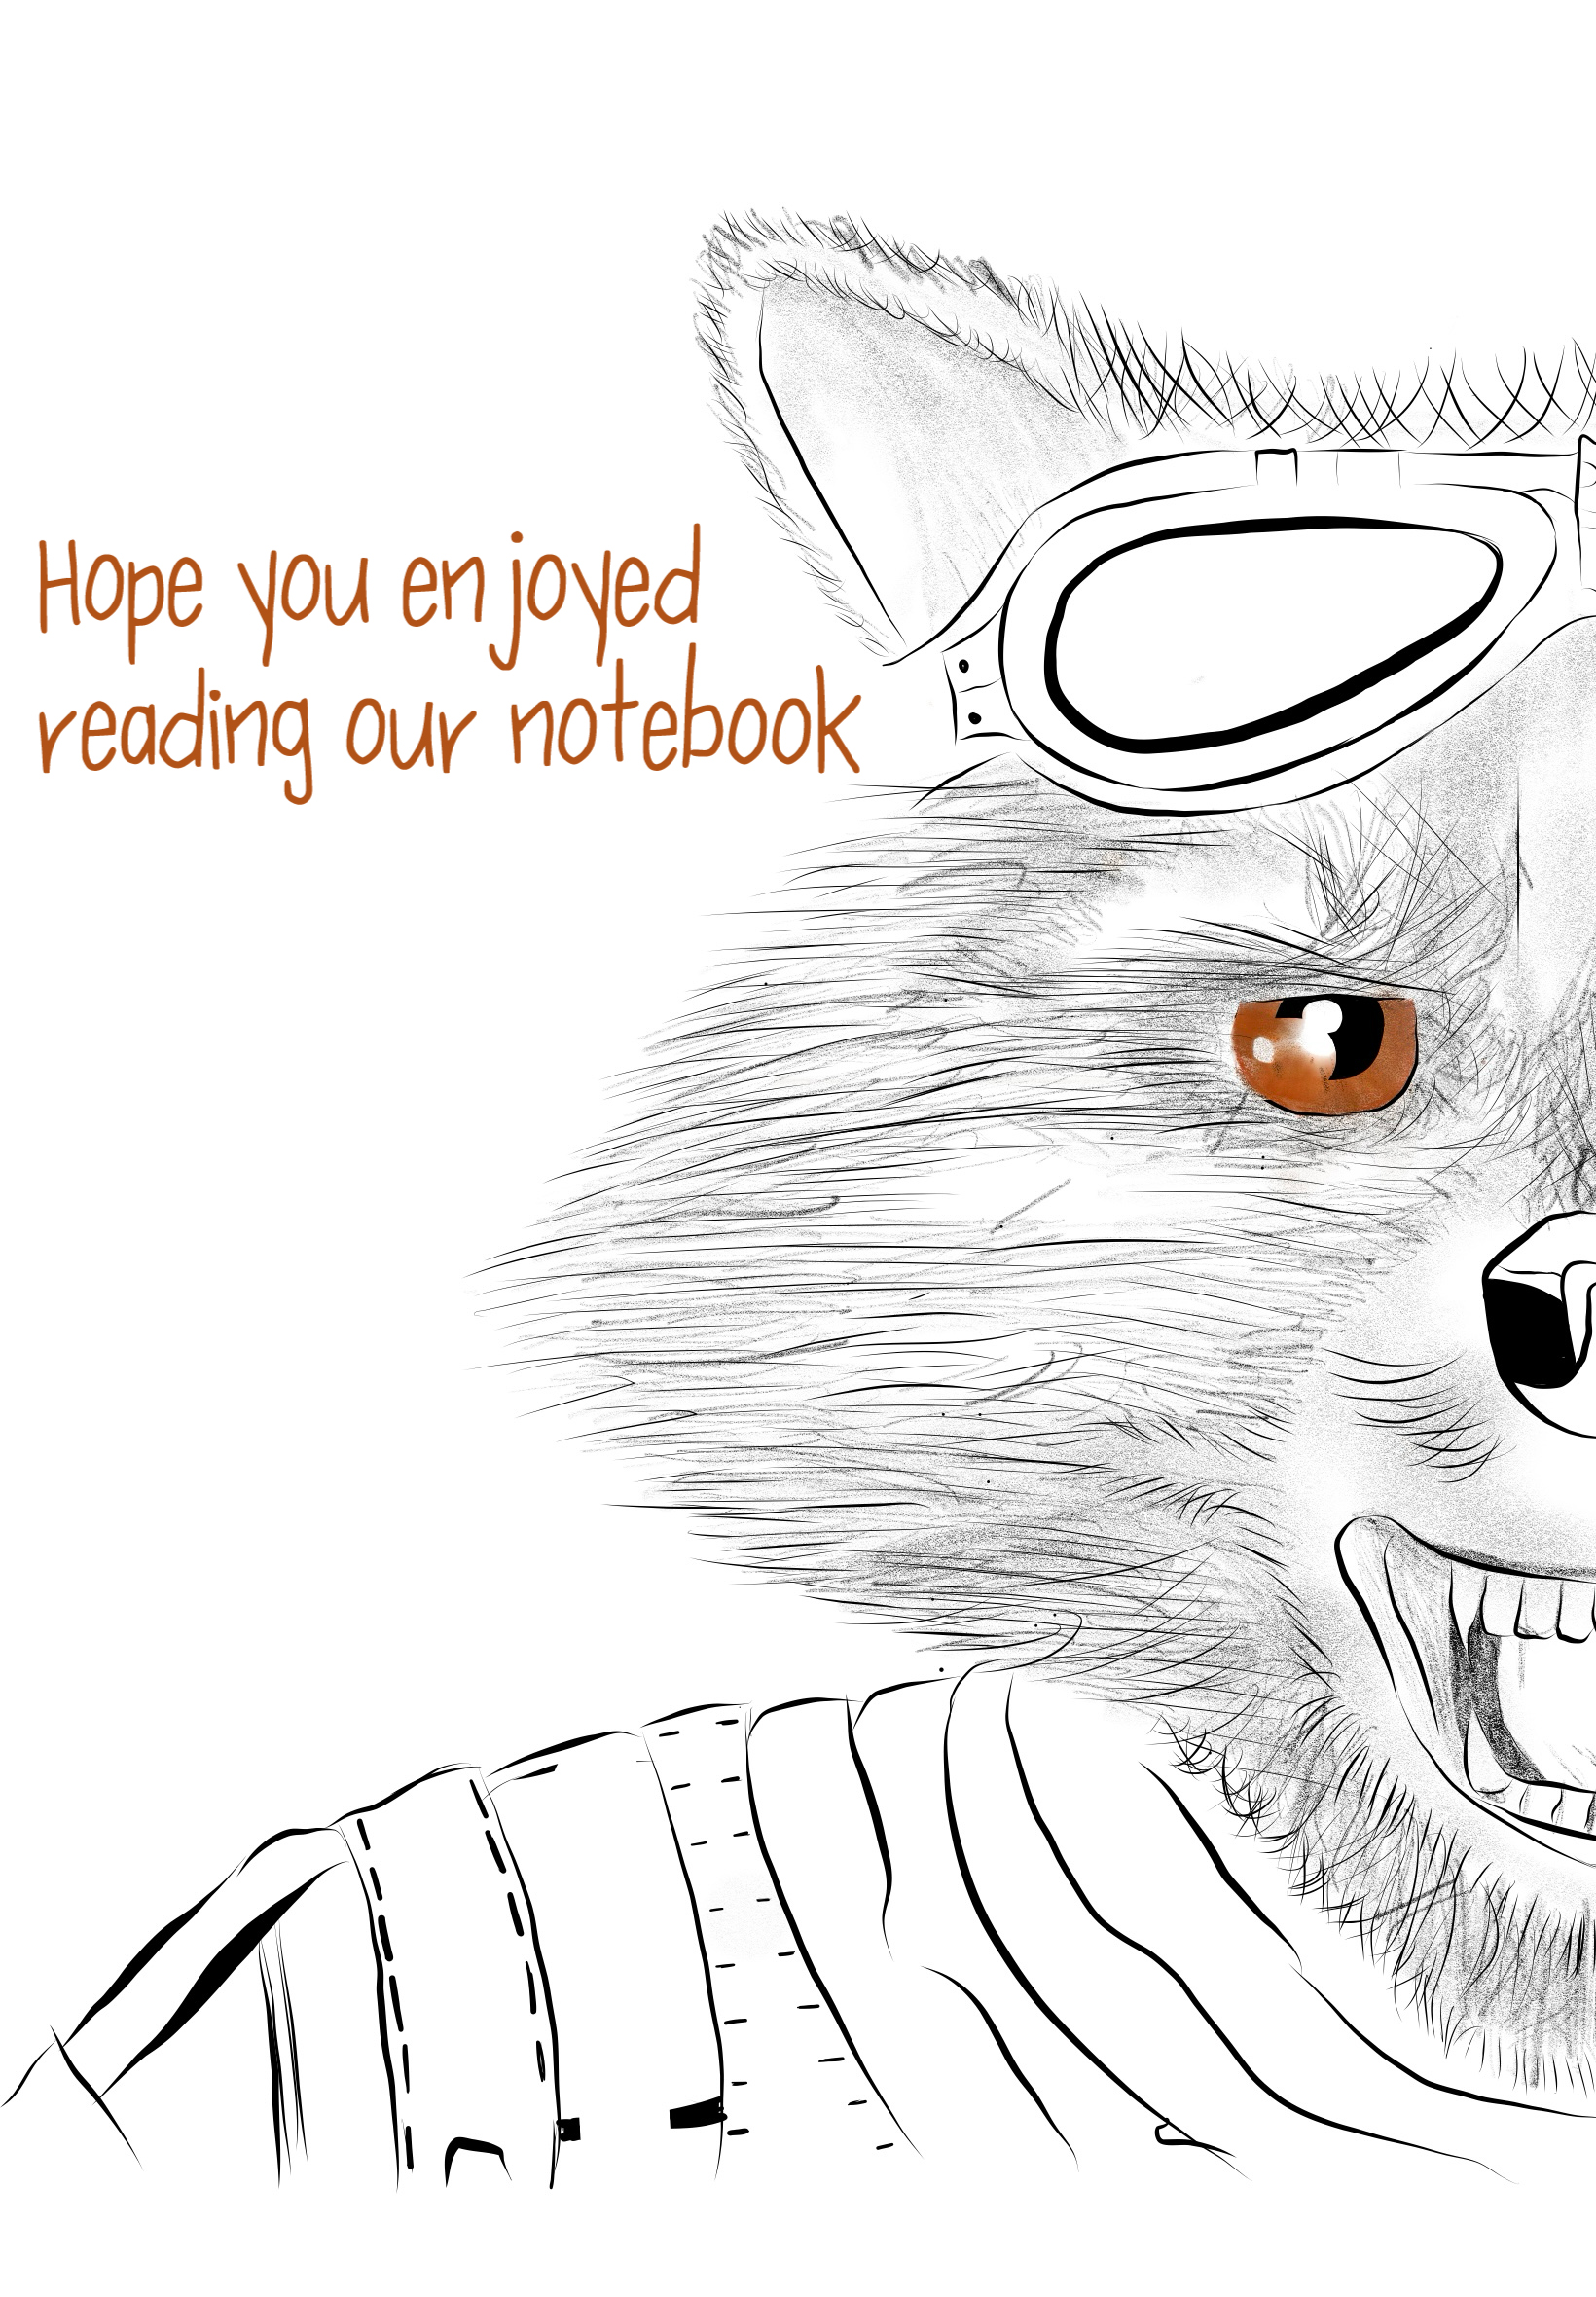

# **List of sources:**

* All the Notebooks from the moodle.
* https://www.kaggle.com/code/fatmakursun/house-price-some-of-regression-models
* https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/code?competitionId=5407&searchQuery=linear+&tagIds=13405&excludeNonAccessedDatasources=true
* https://www.kaggle.com/code/noussaons/linear-regression
* https://www.kaggle.com/code/rbyron/simple-linear-regression-models/notebook
* https://www.kaggle.com/code/furykan/house-of-prices-ensemble-tuning-model-blending
* ChatGPT 4o.